<h1 style="text-align: center;">Physical AI의 Vision-LLM 융합 시청각 멀티모달 시스템</h1>

<br><br>

<div style="text-align: right; color: gray; font-style: italic;">
김규래&emsp;<br>
kkr.kyurae.kim@gmail.com&emsp;
</div><br>

---
---

## 2. Computer Vision 기초

본 세션에서는 OpenCV를 활용한 기초 이미지 처리 기법과 Jetson 환경에서의 실시간 카메라 피드 처리 방법을 다룹니다

이번에 다룰 핵심 내용은 크게 3가지 단계로 나누어 진행합니다.
* 이미지 전처리: 이미지 조정, 색공간 변환, 이미지 Enhancement, 필터링
* 특징 추출: Color Segmentation, Contour 검출, Interest Point 추출
* 객체 추적: SORT, Feature Matching

Python 기반의 Computer Vision 문제를 해결하기 위해서는 OpenCV, NumPy, Matplotlib, scikit-image와 같은 필수 라이브러리를 자유롭게 활용할 수 있어야 합니다.

먼저 JetPack에 기본으로 포함되지 않은 라이브러리를 설치합니다.

이때 주의할 점은 시스템 Python 환경과 가상환경의 라이브러리 버전이 충돌하지 않도록 관리하는 것입니다.<br>
특히 Jetson에서는 OpenCV와 같이 JetPack에서 제공하는 라이브러리가 하드웨어 가속 기능과 연동되어 있으므로, 기존 시스템 라이브러리를 유지하면서 필요한 패키지만 추가 설치하는 방식이 권장됩니다.

```bash
python -m pip install --upgrade pip setuptools wheel
pip uninstall matplotlib-inline
pip install "matplotlib-inline<0.2"
pip install --no-deps \
    scikit-image==0.19.3 \
    imageio==2.19.3 \
    tifffile==2022.5.4 \
    PyWavelets==1.3.0 \
    networkx==2.8.8
```

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage.data

위 코드가 에러 없이 실행되었다면 설치가 잘 되었으니 다음으로 넘어가도 되겠습니다.

---

### A. 이미지 조정

이어서 실습에 사용될 테스트 이미지를 불러와 확인해봅시다.

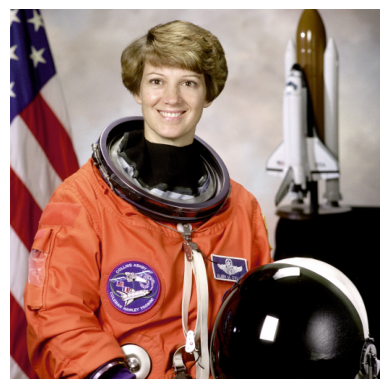

In [4]:
image = skimage.data.astronaut()

plt.imshow(image)
plt.axis("off");

이미지는 결국 픽셀 '배열'입니다.

배열의 크기는 "H x W x C"이며, [row, col, channel]이라고도 표현합니다.

위 이미지는 RGB 이미지이기에 channel의 개수는 3입니다.

In [5]:
image.shape

(512, 512, 3)

저희가 사용하는 astronaut 이미지는 세로와 가로가 512 픽셀이며 각 픽셀마다 3가지 값 (RGB)가 저장되어 있습니다.

`image.shape`에서 알 수 있듯이, 이미지는 NumPy 배열입니다.

그럼 NumPy 방식으로 indexing 하여 픽셀 하나만 골라서 확인해볼까요?

In [6]:
image[0, 0]

array([154, 147, 151], dtype=uint8)

위 결과에서 볼 수 있듯이, 픽셀 하나에는 R,G,B 값이 들어있습니다.

각 픽셀의 데이터 타입은 `uint8` 입니다.

색상을 확인해봅시다.

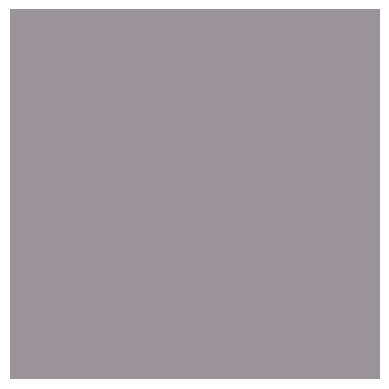

In [7]:
rgb = np.array([154, 147, 151])

color = np.zeros((1, 1, 3), dtype=np.uint8)
color[0, 0] = rgb

plt.imshow(color)
plt.axis("off");

이미지는 원점 (origin)이 좌측 상단입니다. row가 증가하면 아래로, column이 증가하면 우측으로 이동합니다.

In [8]:
image[50, 0]

array([45, 34, 93], dtype=uint8)

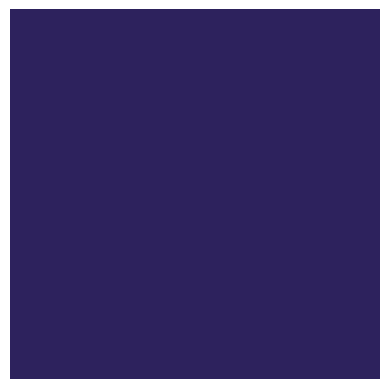

In [9]:
rgb = np.array([45, 34, 93])

color = np.zeros((1, 1, 3), dtype=np.uint8)
color[0, 0] = rgb

plt.imshow(color)
plt.axis("off");

이번에는 NumPy 방식으로 배열을 slicing 해보면 어떻게 될까요?

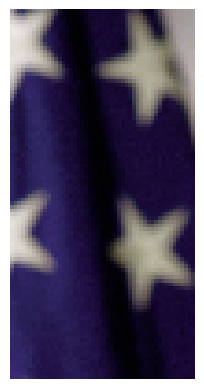

In [10]:
sliced = image[0:100, 0:50]

plt.imshow(sliced)
plt.axis("off");

NumPy slcing을 한다면 이미지를 crop하는 효과를 낼 수 있습니다.

다음으로는 OpenCV 기능을 사용하여 이미지를 회전/반전시켜 봅시다.

ROTATE_90_CLOCKWISE = 0
ROTATE_90_COUNTERCLOCKWISE = 2
ROTATE_180 = 1


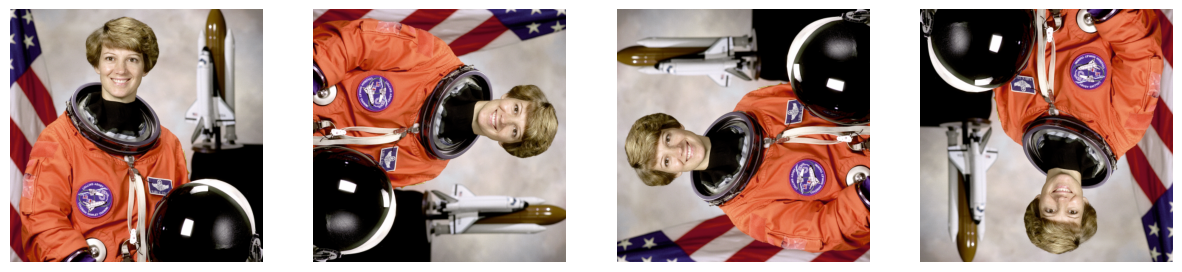

In [11]:
plt.figure(figsize=(15,6))

plt.subplot(1,4,1), plt.imshow(image)
plt.subplot(1,4,2), plt.imshow(cv2.rotate(image.copy(), cv2.ROTATE_90_CLOCKWISE))
plt.subplot(1,4,3), plt.imshow(cv2.rotate(image.copy(), cv2.ROTATE_90_COUNTERCLOCKWISE))
plt.subplot(1,4,4), plt.imshow(cv2.rotate(image.copy(), cv2.ROTATE_180))

for ax in plt.gcf().axes:
    ax.axis("off")

print(f"ROTATE_90_CLOCKWISE = {cv2.ROTATE_90_CLOCKWISE}")
print(f"ROTATE_90_COUNTERCLOCKWISE = {cv2.ROTATE_90_COUNTERCLOCKWISE}")
print(f"ROTATE_180 = {cv2.ROTATE_180}")

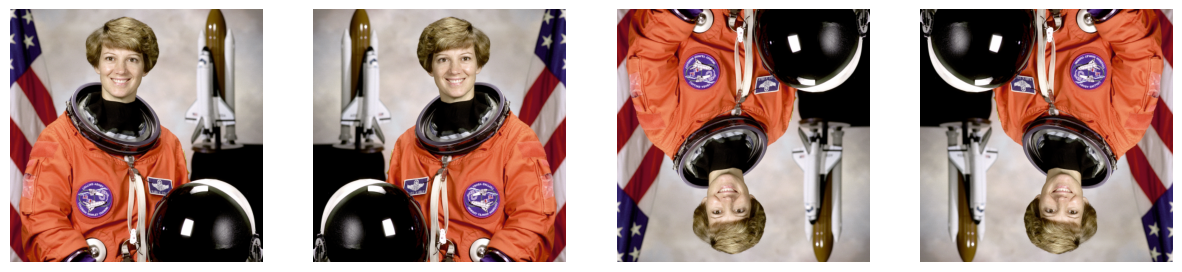

In [12]:
plt.figure(figsize=(15,6))

plt.subplot(1,4,1), plt.imshow(image)
plt.subplot(1,4,2), plt.imshow(cv2.flip(image.copy(), 1))
plt.subplot(1,4,3), plt.imshow(cv2.flip(image.copy(), 0))
plt.subplot(1,4,4), plt.imshow(cv2.flip(image.copy(), -1))

for ax in plt.gcf().axes:
    ax.axis("off")

이미지는 기본적으로 픽셀 값을 [0,255]으로 저장하며, 데이터 타입은 `uint8`입니다.

In [13]:
image.dtype

dtype('uint8')

데이터 타입을 [0,255] 8비트 정수에서 [0,1] 32비트 실수로 변환해봅시다.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


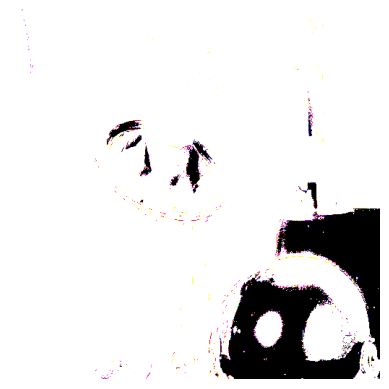

In [14]:
plt.imshow(image.astype(np.float32))
plt.axis("off");

Matplotlib이 실수 값은 [0,1]인데 왜 그 밖의 숫자를 건네주는지 불평하는군요.

각 픽셀 값을 255로 나눠줍시다.

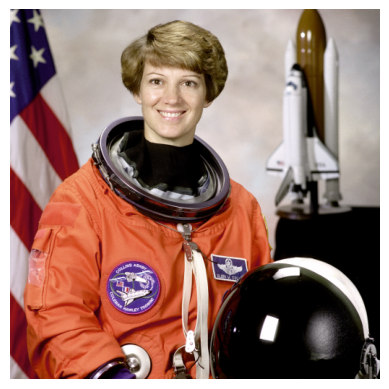

In [15]:
plt.imshow(image.astype(np.float32) / 255.)
plt.axis("off");

이제 32비트 실수를 사용하여 이전과 같은 이미지를 볼 수 있습니다.

---

### B. 색공간 변환

색공간 (Color Space)이란?
* 색을 일정한 기준으로 표현하는 방식
* 색공간마다 표현 가능한 색의 범위가 다름
* 일관된 색 표현을 위해 색공간 통일
* 색공간 변환을 통해 이미지 전처리 효율을 극대화

#### $1)$ RGB와 BGR 색공간

기본적으로 Matplotlib은 RGB, OpenCV는 BGR 색공간을 사용합니다.

이번에는 OpenCV로 이미지를 불러옵시다.

In [16]:
img_bgr = cv2.imread("src/images/1665_Girl_with_a_Pearl_Earring.jpg")
img_bgr = img_bgr.astype(np.float32) / 255.

OpenCV는 `cv2.imread` 함수를 사용하여 로컬에 저장되어 있는 이미지를 불러올 수 있습니다.

이제 Matplotlib으로 이미지를 확인해봅시다.

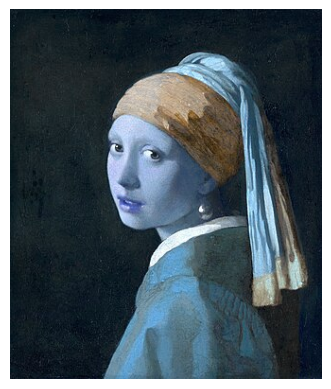

In [17]:
plt.imshow(img_bgr)
plt.axis("off");

무언가 확실히 잘못됐죠?

그 이유는 OpenCV는 기본적으로 BGR 순서로 이미지를 읽어오지만, Matplotlib은 RGB 순서 기준으로 이미지를 해석하기 때문입니다.

따라서 최종적으로 이미지를 렌더링할 시각화 도구의 색공간 기준으로 변환해 주어야 합니다.

OpenCV의 `cv2.cvtColor` 함수를 사용하여 변환해봅시다.

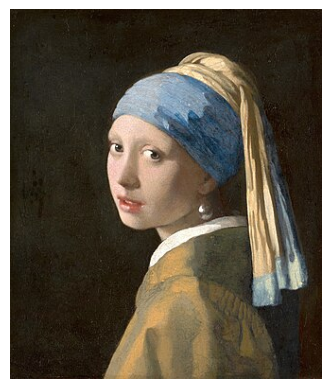

In [18]:
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off");

#### $2)$ Grayscale

동일한 방식으로 흑백 (grayscale)로 변환할 수 있습니다.

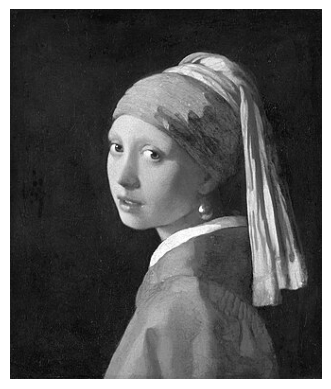

In [19]:
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.imshow(img_gray, cmap="gray")
plt.axis("off");

우리의 우주비행사도 흑백으로 변환해 볼까요?

In [20]:
# TODO: astronaut 이미지를 흑백으로 변환하여 렌더링

두 결과물이 다른 이유:

$$
\text{Gray} = 0.299R + 0.587G + 0.114B
$$

#### $3)$ HSV 색공간

HSV 색공간:
* H (Hue): 색상
  * 일반: $0^\circ$ ~ $360^\circ$
  * OpenCV: $0^\circ$ ~ $179^\circ$ (uint8), $0.0^\circ$ ~ $360.0^\circ$ (float32)
* S (Saturation): 채도
  * 일반: 0 ~ 100%
  * OpenCV: 0 ~ 255 (uint8), 0.0 ~ 1.0 (float32)
* V (Value): 명도
  * 일반: 0 ~ 100%
  * OpenCV: 0 ~ 255 (uint8), 0.0 ~ 1.0 (float32)

이제 HSV 색공간으로 변환하여 각 channel을 시각화해 봅시다.

`cv2.split(이미지)` 함수를 사용하면 이미지의 각 channel을 분리할 수 있습니다.

In [21]:
# TODO: astronaut 이미지를 HSV 색공간으로 변환
# TODO: HSV 각 채널을 분리한 뒤 subplot에 시각화

image_hsv = ...
h, s, v = cv2.split(image_hsv)

plt.figure(figsize=(15,8))

plt.subplot(...), plt.imshow(...), plt.title('H Channel (Hue)')
plt.subplot(...), plt.imshow(...), plt.title('S Channel (Saturation)')
plt.subplot(...), plt.imshow(...), plt.title('V Channel (Value)')

for ax in plt.gcf().axes:
    ax.axis("off")

error: OpenCV(4.8.0) :-1: error: (-5:Bad argument) in function 'split'
> Overload resolution failed:
>  - m is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'm'


HSV 각 채널을 분리하였다면 각 색상/채도/명도를 조절하여 이미지를 수정할 수 있습니다.

H (색상) 각도를 shift하여 색상을 변경해 봅시다.

H의 범위가 (float32 기준) $0.0^\circ$ ~ $360.0^\circ$이기에 360도가 넘어가면 0으로 순환하도록 코드를 작성합시다.

In [ ]:
image = skimage.data.astronaut()
image = image.astype(np.float32) / 255.

# TODO: 이미지를 HSV 색공간으로 변환
# TODO: HSV 이미지의 각 채널 분리
# TODO: H 각도를 증가시켜 색상 변경 (360도 초과하지 않도록 유의)
# TODO: 각 채널을 cv2.merge([h, s, v])로 결합
# TODO: 색공간을 다시 변환하여 이미지 출력

S (채도) 값을 감쇠시켜 채도를 낮춰봅시다.

S의 범위가 (float32 기준) 0.0 ~ 1.0 이기에 범위에서 벗어나지 않도록 코드를 작성합시다.

In [ ]:
image = skimage.data.astronaut()
image = image.astype(np.float32) / 255.

# TODO: 이미지를 HSV 색공간으로 변환
# TODO: HSV 이미지의 각 채널 분리
# TODO: S 값에 배율을 적용하여 채도 감쇠
# TODO: np.clip(s, 0, 1)을 사용하여 최소/최대값 설정
# TODO: 각 채널을 cv2.merge([h, s, v])로 결합
# TODO: 색공간을 다시 변환하여 이미지 출력

V (명도) 값을 증폭시켜 명도를 높여봅시다.

V의 범위가 (float32 기준) 0.0 ~ 1.0 이기에 범위에서 벗어나지 않도록 코드를 작성합시다.

In [ ]:
image = skimage.data.astronaut()
image = image.astype(np.float32) / 255.

# TODO: 이미지를 HSV 색공간으로 변환
# TODO: HSV 이미지의 각 채널 분리
# TODO: V 값에 배율을 적용하여 명도 증폭
# TODO: np.clip(v, 0, 1)을 사용하여 최소/최대값 설정
# TODO: 각 채널을 cv2.merge([h, s, v])로 결합
# TODO: 색공간을 다시 변환하여 이미지 출력

앞선 실습에서 확인했듯이, HSV 색공간은 색상/채도/명도가 독립적으로 분리되어 있습니다.

따라서 각 채널을 개별적으로 조절하여 이미지를 원하는 대로 변형할 수 있습니다.

---

### C. 필터링

필터링 (Filtering)이란?
* 불필요한 성분 (노이즈)을 제거하고 원하는 특징만 선별하는 이미지 전처리 과정
* Kernel을 통한 합성곱 (Convolution) 연산 수행

필터링의 종류
* Smoothing: 이미지에서 노이즈를 제거하여 부드럽게 만드는 과정 (blur)
  * Box Filter (박스 블러)
  * Gaussian Filter (가우시안 블러)
* Sharpening: 이미지에서 세부 디테일을 강조하여 선명하게 만드는 과정

#### $1)$ Box Filter

OpenCV의 `cv2.blur` 함수를 사용해 Box Filter를 적용해봅시다.

In [ ]:
box_blur = cv2.blur(image, (11,11))

plt.imshow(box_blur)
plt.axis("off");

#### $2)$ Gaussian Filter

OpenCV의 `cv2.GaussianBlur` 함수를 사용해 Gaussian Filter를 적용해봅시다.

In [ ]:
gaussian_blur = cv2.GaussianBlur(image, (11,11), 0)

plt.imshow(gaussian_blur)
plt.axis("off");

Box Filter vs. Gaussian Filter 비교

In [ ]:
plt.figure(figsize=(16,8))

plt.subplot(1,2,1), plt.imshow(box_blur), plt.title('Box Filter')
plt.subplot(1,2,2), plt.imshow(gaussian_blur), plt.title('Gaussian Filter')

for ax in plt.gcf().axes:
    ax.axis("off")

이번에는 Kernel 크기에 따른 변화를 확인해봅시다.

우선 Jupyter Notebook에서 위젯 (슬라이더)를 구현하기 위하여 `ipywidgets`를 설치해야 합니다.

```bash
pip install ipywidgets
```

설치가 완료되었다면 아래 코드를 실행해봅시다.

In [22]:
from ipywidgets import interact

def change_kernel(kernel_size):
    # 홀수 kernel만 사용
    if kernel_size % 2 == 0:
        kernel_size += 1

    b_blur = cv2.blur(image, (kernel_size, kernel_size))
    g_blur = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)

    plt.figure(figsize=(16,8))
    plt.subplot(1,2,1), plt.imshow(b_blur), plt.title(f"Box Filter ({kernel_size}x{kernel_size})")
    plt.subplot(1,2,2), plt.imshow(g_blur), plt.title(f"Gaussian Filter ({kernel_size}x{kernel_size})")

    for ax in plt.gcf().axes:
        ax.axis("off")

    plt.show()

interact(change_kernel, kernel_size=(1,101,2));

interactive(children=(IntSlider(value=51, description='kernel_size', max=101, min=1, step=2), Output()), _dom_…

#### $3)$ Sharpening Filter

다음으로는 sharpening filter를 적용해봅시다.

안타깝게도 OpenCV에 `cv2.blur`, `cv2.GaussianBlur`와 같은 sharpening 함수가 존재하지 않습니다.

그러므로 NumPy 배열을 사용하여 kernel을 직접 만들어 `cv2.filter2D` 함수를 통해 Sharpening Filter를 적용해봅시다.

`cv2.filter2D(src, ddepth, kernel)`
* `src`: 원본 이미지
* `ddepth`: 데이터 타입 (-1은 원본 이미지와 동일한 데이터 타입)
* `kernel`: 커널 배열

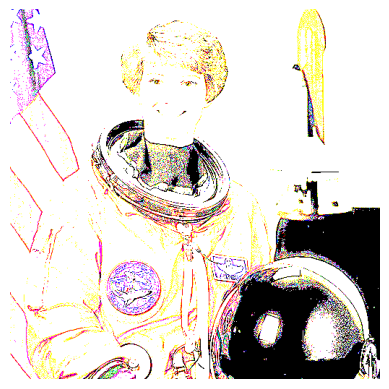

In [23]:
sharp_kernel = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]], dtype=np.float32)

sharpened = cv2.filter2D(image, cv2.CV_32F, sharp_kernel)
sharpened = np.clip(sharpened, 0, 1)

plt.imshow(sharpened)
plt.axis("off");

Sharpening Kernel을 변경하여 이미지를 더욱 선명하게 만들어봅시다.

In [24]:
# TODO: 기존 sharpening kernel 포함하여 총 3가지 kernel을 적용한 결과를 원본 이미지와 함께 비교하는 subplot 생성

#### $4)$ Border Type

필터링을 적용할 때 borderType을 지정하여 차이를 확인해봅시다.

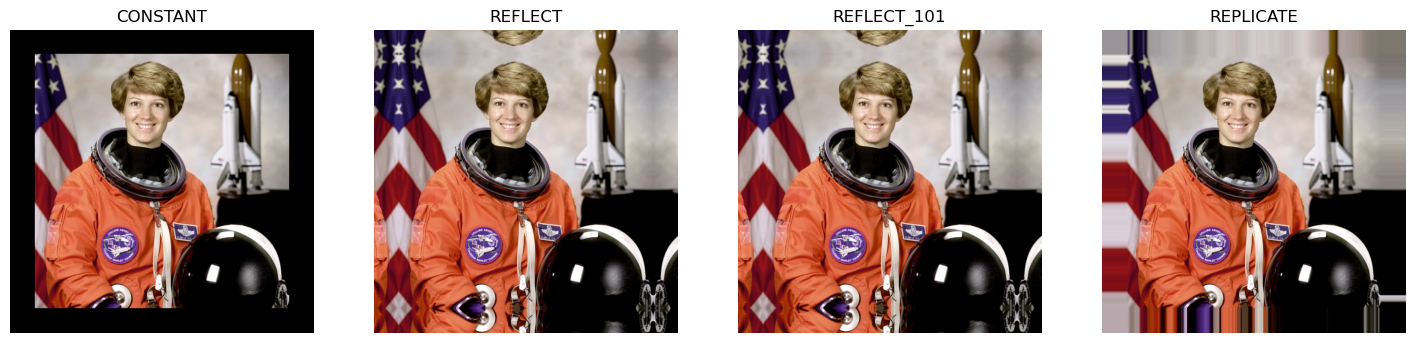

In [28]:
# TODO: 각 borderType을 적용한 결과 이미지와 제목이 적혀있는 subplot 생성

kernel_size = (101, 101)

border_types = [
    (cv2.BORDER_CONSTANT, "CONSTANT"),
    (cv2.BORDER_REFLECT, "REFLECT"),
    (cv2.BORDER_REFLECT_101, "REFLECT_101"),
    (cv2.BORDER_REPLICATE, "REPLICATE"),
]

plt.figure(figsize=(18, 8))

# 각 borderType을 적용하여 subplot 생성
for i, (border_type, title) in enumerate(border_types):
    bordered_image = cv2.copyMakeBorder(
        image,
        50, 50, 50, 50,
        borderType=border_type
    )

    plt.subplot(1, 4, i + 1)
    plt.imshow(bordered_image)
    plt.title(title)
    plt.axis("off")

plt.show()

# TODO: enumerate과 for loop을 사용하여 효율적으로 subplot 생성

테두리 부근에만 영향이 미치므로 전반적인 차이는 크지 않지만, `cv2.BORDER_CONSTANT` 방식은 결과가 명확하게 다른 것을 확인할 수 있습니다.

---

### D. Edge Detection

이미지 주파수 (Image Frequency):
* 저주파 (Low Frequency)
  * 하늘, 피부, 벽면, 부드러운 음영, 기본 형태
  * 없애면 윤곽선 스케치 (음영/형태 사라짐)
* 고주파 (High Frequency)
  * 경계선, 무늬, 질감, 거친 표면, 노이즈
  * 없애면 흐릿한 이미지 (질감/노이즈 사라짐)

저역통과 필터 (Low-pass Filter) vs. 고역통과 필터 (High-pass Filter):
* LPF
  * 저주파만 통과 (고주파는 억제)  →  흐릿한 이미지
  * Box Filter, Gaussian Filter
* HPF
  * 고주파만 통과 (저주파는 억제)  →  윤곽선 스케치
  * Residual Extraction (Unsharp Masking), Sobel Filter, Canny Edge Detection

#### $1)$ Residual Extraction

Residual Extraction을 적용하여 High-pass Filter의 결과물인 윤곽선 스케치 이미지를 만들어봅시다.

우선 'sky.png' 이미지를 `cv2.imread` 함수로 불러와 grayscale로 만듭니다.

그 다음, Gaussian Filter를 통해 저주파 이미지를 생성합니다.

기존 이미지에서 저주파 이미지를 감산 (subtract)하여 고주파 이미지를 생성 (High-pass Filter 적용)합니다.

이미지 감산은 `cv2.subtract(이미지, 저주파_이미지)` 함수를 사용하면 됩니다.

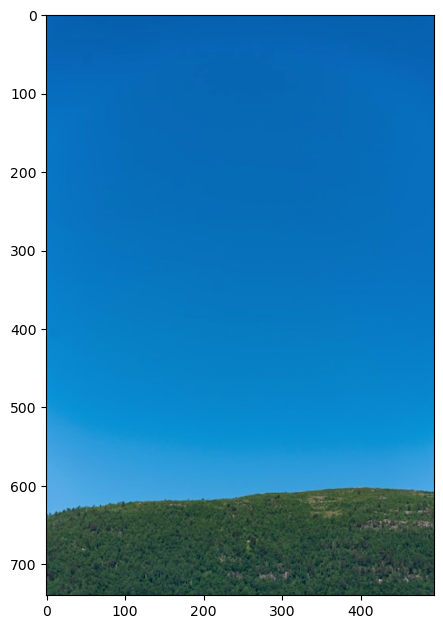

In [49]:
img_path = 'src/images/sky.png'
sky_img = cv2.imread(img_path)

plt.figure(figsize=(5,10))
plt.imshow(cv2.cvtColor(sky_img, cv2.COLOR_BGR2RGB))

# TODO: 원본 이미지 확인

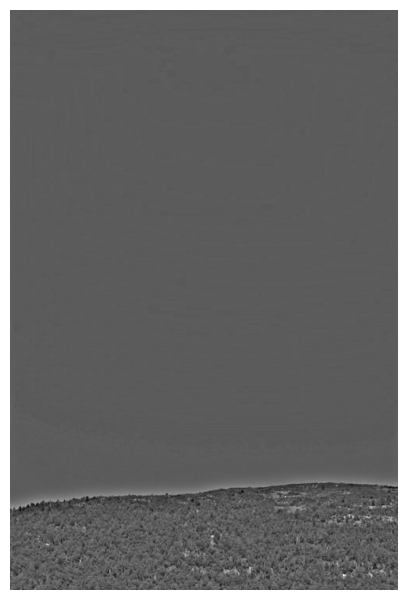

In [56]:
# TODO: 이미지를 grayscale로 변환
sky_img_gray = cv2.cvtColor(sky_img, cv2.COLOR_BGR2GRAY)

# TODO: 이미지를 float32로 변환
sky_img_gray = sky_img_gray.astype(np.float32) / 255.

# TODO: Gaussian Filter 적용 (Kernel 사이즈는 55x55)
sky_blur = cv2.GaussianBlur(sky_img_gray, (55, 55), 0)

# TODO: cv2.subtract를 사용하여 원본에서 저주파 성분 차감 (High-pass Filter)
sky_hf = cv2.subtract(sky_img_gray, sky_blur)

# TODO: 고주파 이미지 확인 (cmap 설정)
plt.figure(figsize=(5, 10))
plt.imshow(sky_hf, cmap="gray")
plt.axis("off");

#### $2)$ Unsharp Masking

Unsharp Masking을 적용하여 기존 이미지의 edge를 강조해봅시다.

위 과정에서 만든 고주파 이미지를 원본 흑백 이미지와 합칩니다.

`cv2.add(원본_이미지, 고주파_이미지)` 함수를 사용하면 됩니다.

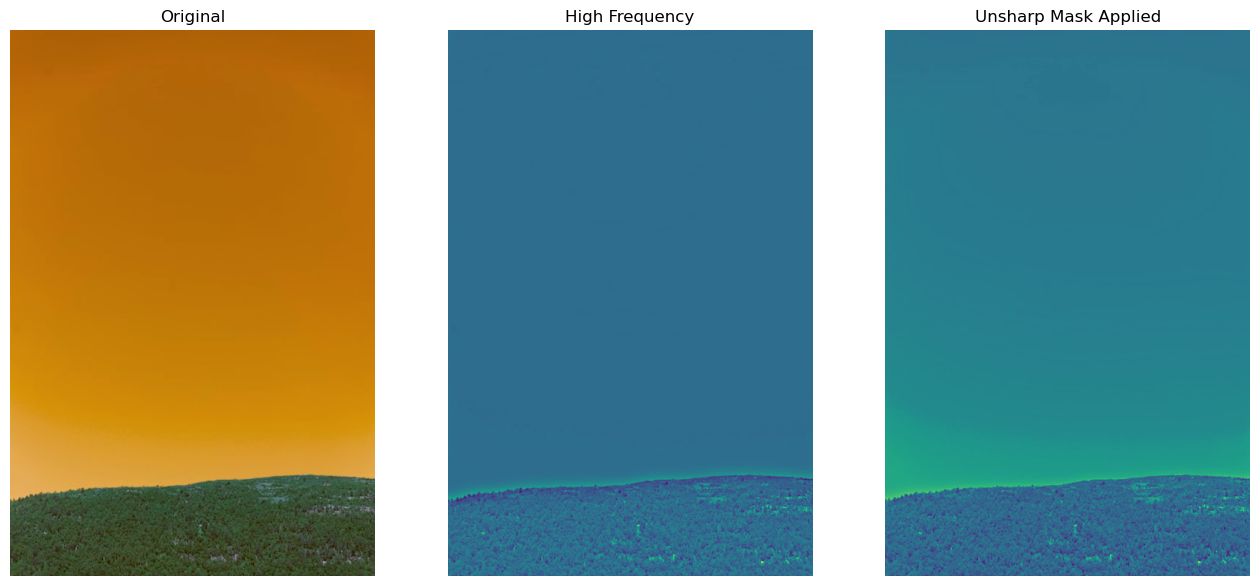

In [62]:
# TODO: cv2.add를 사용하여 원본과 고주파 이미지를 합산
unsharp_mask_applied = cv2.add(sky_img_gray, sky_hf)

# TODO: subplot 3개 (원본 흑백 이미지, 고주파 이미지, unsharp mask 적용된 이미지) 생성
plt.figure(figsize=(16,8))
plt.subplot(1,3,1), plt.imshow(sky_img), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(sky_hf), plt.title("High Frequency")
plt.subplot(1,3,3), plt.imshow(unsharp_mask_applied), plt.title("Unsharp Mask Applied")

for ax in plt.gcf().axes:
    ax.axis("off")

#### $3)$ Sobel Filter

Sobel Filter:
* 이미지의 미분 (밝기 변화율)을 이용하여 밝기 변화가 큰 edge 검출
* 미분 커널 ($G_x$, $G_y$)을 이용해 수평/수직 방향의 gradient를 계산
* 두 방향의 gradient를 조합하여 edge 방향과 강도 (magnitude)를 얻음

dx:
* 세로 방향 edge 강도
* Kernel이 오른쪽 방향 (x축 방향)으로 이동하며 edge 검출
* `cv2.Sobel(src, ddepth, dx=1, dy=0, dst, ksize)` → `dx=1` 설정

dy:
* 가로 방향 edge 강도
* Kernel이 아래쪽 방향 (y축 방향)으로 이동하며 edge 검출
* `cv2.Sobel(src, ddepth, dx=0, dy=1, dst, ksize)` → `dx=1` 설정

`cv2.Sobel(src, ddepth, dx, dy, dst, ksize)`
* `src`: 원본 이미지
* `ddepth`: 데이터 타입 (주로 `cv2.CV_64F`로 설정)
* `dx`: x-방향 미분 차수 (세로 방향 edge 검출시 dx=1, dy=0 으로 설정)
* `dy`: y-방향 미분 차수 (가로 방향 edge 검출시 dx=0, dy=1 으로 설정)
* `dst`: 연산 결과를 저장할 출력 배열 (destination), Python에서는 주로 직접 지정하지 않음
* `ksize`: 커널 크기, 주로 `dst`를 지정하지 않기에 `ksize=`처럼 argument 이름도 명시해야 함

Sobel Filter의 dx와 dy를 구해 시각화해 봅시다.

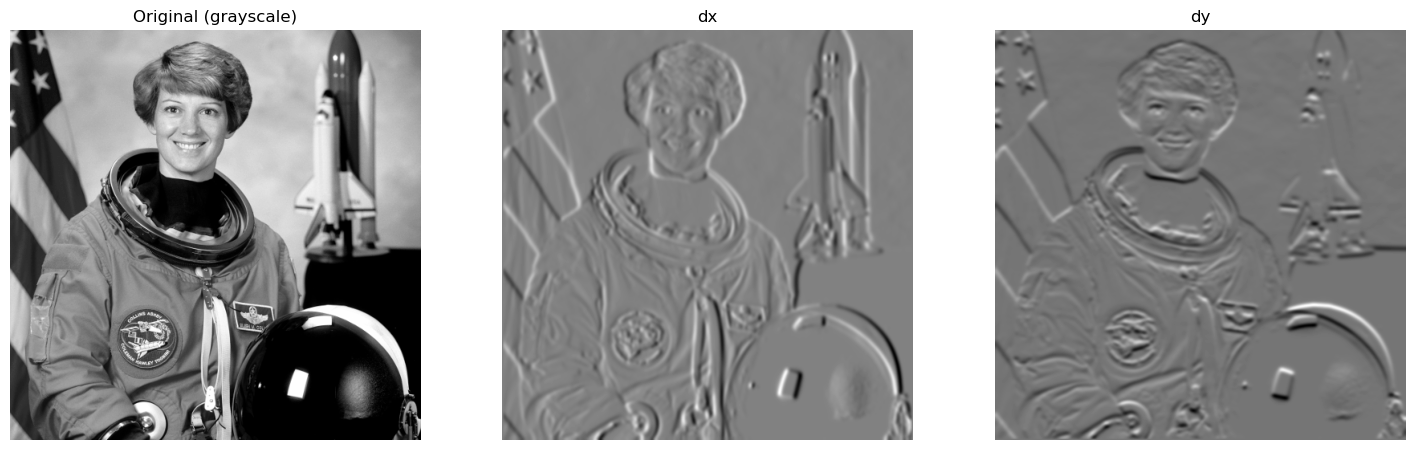

In [63]:
image = skimage.data.astronaut()

# TODO: RGB2GRAY/BGR2GRAY 둘 중 선택 고려하여 image를 grayscale로 변환 (skimage.data.astronaut은 RGB, cv2.imread는 BGR)
image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# TODO: image_gray를 float32로 변환
image_gray = image_gray.astype(np.float32) / 255.

# TODO: image_gray에 Gaussian Filter 적용 (Kernel 크기 11x11)
image_blur = cv2.GaussianBlur(image_gray, (11, 11), 0)

# TODO: dx, dy 생성
sobel_x = cv2.Sobel(image_blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image_blur, cv2.CV_64F, 0, 1, ksize=3)

# TODO: subplot 3개 (원본 흑백 이미지, dx, dy) 생성
plt.figure(figsize=(18,8))
plt.subplot(1, 3, 1), plt.imshow(image_gray, cmap="gray"), plt.title("Original (grayscale)")
plt.subplot(1, 3, 2), plt.imshow(sobel_x, cmap="gray"), plt.title("dx")
plt.subplot(1, 3, 3), plt.imshow(sobel_y, cmap="gray"), plt.title("dy")

for ax in plt.gcf().axes:
    ax.axis("off")

cv2.magnitude:
* Sobel Filter의 edge 강도 (magnitude)
* 가로/세로 edge가 아닌 전체 대각선 포함 edge 강도
* 가로/세로 방향으로 찾은 edge를 하나로 뭉쳐서 찾은 전체 edge

$$magnitude = \sqrt{dx^2 + dy^2}$$

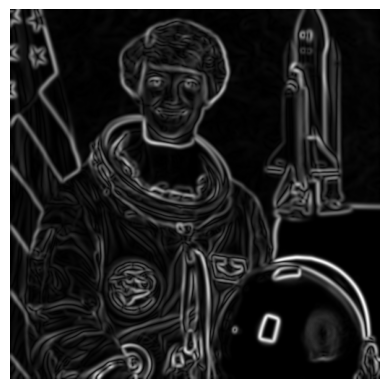

In [64]:
sobel_mag = cv2.magnitude(sobel_x, sobel_y)

plt.imshow(sobel_mag, cmap="gray")
plt.axis("off");

convertScaleAbs:
* Magnitude (edge 강도)를 절대값으로 변환
* 복잡한 결과를 일반 이미지 (0 ~ 255, 0.0 ~ 1.0) 형태로 변환

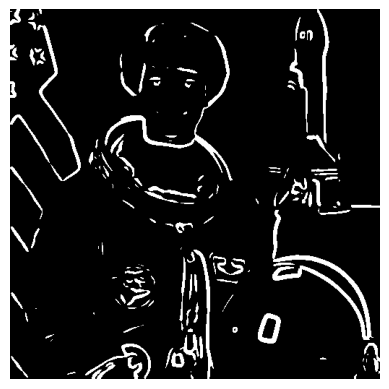

In [65]:
sobel_mag_abs = cv2.convertScaleAbs(sobel_mag)

plt.imshow(sobel_mag_abs, cmap="gray")
plt.axis("off");

Sobel Filter:
* 장점
  * 매우 빠른 속도
* 단점
  * 배경 노이즈에 취약
  * 두꺼운 edge


#### $4)$ Canny Edge Detection

Sobel Filter의 단점을 보완하는 "Canny Edge Detection"

기존 Sobel Filter의 두꺼운 edge를 매우 얇고 정확한 edge로 검출하는 알고리즘/기법

Canny Edge Detection의 과정:
1. Gaussian Smoothing
   * 노이즈 제거  (edge 검출에 치명적)
2. Sobel Filter
   * Edge 후보 검출  (아직 너무 굵은 edge)
3. Non-maximum Suppression (비최대 억제, NMS)
   * Gradient 방향 기준으로 local maximum만 유지  (나머지 0으로 설정)
4. Hysteresis Thresholding (히스테레시스 임계값 처리)
   * Local maximum들을 이중 임계값으로 처리
   * 중간값 (보류된 픽셀)은 “연결성” 추적

Canny Edge Detection을 구현해봅시다.

In [66]:
image = skimage.data.astronaut()

image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
image_gray = image_gray.astype(np.float32) / 255.

canny_edge = cv2.Canny(image_gray, 50, 150)

plt.imshow(canny_edge, cmap="gray")
plt.axis("off");

error: OpenCV(4.8.0) /home/ubuntu/opencv_build/opencv/modules/imgproc/src/canny.cpp:829: error: (-215:Assertion failed) _src.depth() == CV_8U in function 'Canny'


Sobel Filter와 동일한 방식으로 흑백 이미지를 float32로 변환하였더니 에러가 발생합니다.

"`_src.depth() == CV_8U in function 'cv::Canny'`"

`cv::Canny` 함수는 `CV_8U` 데이터 타입을 필요로 한다고 명시되어 있습니다.

그러므로 float32로 데이터 변환을 하면 안됩니다.

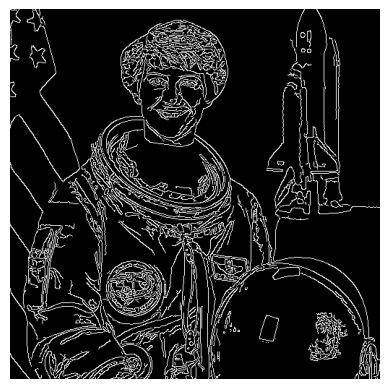

In [67]:
image = skimage.data.astronaut()

image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
# 해당 코드 제외: image_gray = image_gray.astype(np.float32) / 255.

canny_edge = cv2.Canny(image_gray, 50, 150)

plt.imshow(canny_edge, cmap="gray")
plt.axis("off");

이제는 문제 없이 이미지가 렌더링됩니다.

확연히 Sobel Filter보다 edge가 더 얇고 정확해진 것을 확인할 수 있습니다.

In [ ]:
plt.figure(figsize=(16,8))

plt.subplot(1,2,1), plt.imshow(sobel_mag_abs, cmap="gray"), plt.title('Sobel Filter')
plt.subplot(1,2,2), plt.imshow(canny_edge, cmap="gray"), plt.title('Canny Edge Detection')

for ax in plt.gcf().axes:
    ax.axis("off")

---

### E. Color Segmentation

색상 기반 분할 (Color Segmentation)이란?
* 기법 :   색상 기반 분할 (Color Segmentation)
* 설명 :   원하는 특정 색상만 분리/추출
* 방법 :   색상 임계값 처리  (Color Thresholding)
* 결과 :   이진 마스크  (Binary Mask)

이미지 내 빨간색 color thresholding을 통해 이진 마스크 (binary mask)를 생성해봅시다.

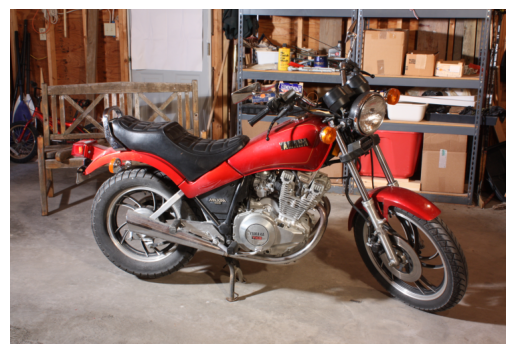

In [68]:
motor = skimage.data.stereo_motorcycle()[0]

plt.imshow(motor)
plt.axis("off");

우선 color thresholding을 위해 이미지를 HSV 색공간으로 변환해줍시다.

그 다음, `cv2.inRange(hsv_이미지, color_lower, color_upper)` 함수를 사용하여 mask를 생성합니다.

빨강은 $0^\circ$에 가깝기에 H값 $0^\circ$ ~ ($0$ + $\theta)^\circ$와 $(180-\theta)^\circ$ ~ $180^\circ$ 두 가지 mask를 bitwise OR로 연산합니다.

In [69]:
def update_mask(h_upper1=10, h_lower2=170):
    lower1 = np.array([0, 100, 50])
    upper1 = np.array([h_upper1, 255, 255])
    lower2 = np.array([h_lower2, 100, 50])
    upper2 = np.array([180, 255, 255])

    # 이미지를 HSV 색공간으로 변환
    motor_hsv = cv2.cvtColor(motor, cv2.COLOR_RGB2HSV)

    # Mask 생성
    mask1 = cv2.inRange(motor_hsv, lower1, upper1)
    mask2 = cv2.inRange(motor_hsv, lower2, upper2)
    mask = cv2.bitwise_or(mask1, mask2)
    #빨간색은 0도에서 시작하기에 두개로 구분짓고 or연산한다

    plt.figure(figsize=(16,8))

    plt.subplot(1,2,1), plt.imshow(motor), plt.title("Original")
    plt.subplot(1,2,2), plt.imshow(mask, cmap="gray"), plt.title(f"H: 0~{h_upper1}, {h_lower2}~180")

    for ax in plt.gcf().axes:
        ax.axis("off")

    plt.show()

# 슬라이더로 upper/lower 값 추측
interact(update_mask, h_upper1=(0, 30, 1), h_lower2=(150, 180, 1));

interactive(children=(IntSlider(value=10, description='h_upper1', max=30), IntSlider(value=170, description='h…

선택한 값을 아래 코드에 적용

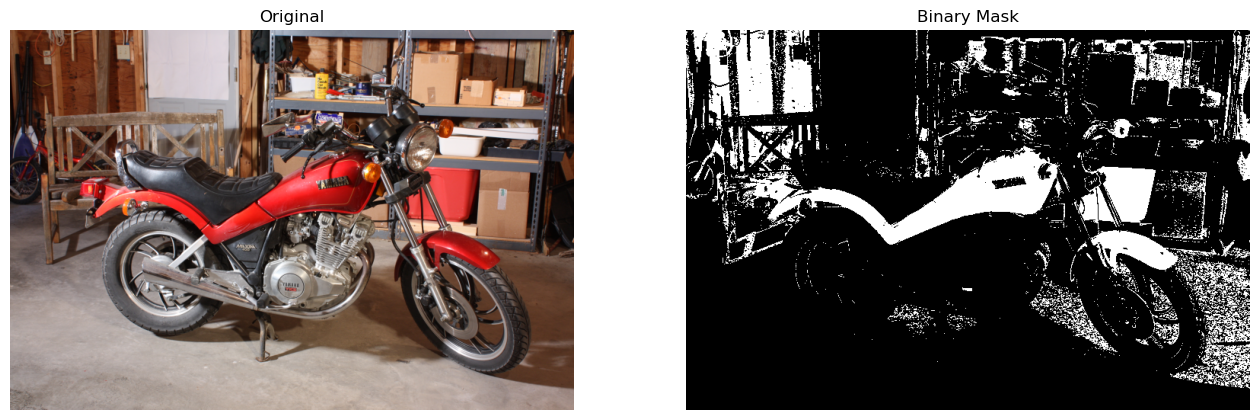

In [72]:
# TODO: 빈칸에 선택한 값 지정
red_lower1 = np.array([0, 100, 50])
red_upper1 = np.array([10, 255, 255])
red_lower2 = np.array([170, 100, 50])
red_upper2 = np.array([180, 255, 255])

# TODO: HSV로 색공간 변환
motor_hsv = cv2.cvtColor(motor, cv2.COLOR_RGB2HSV)

# TODO: Mask 생성
mask_hsv1 = cv2.inRange(motor_hsv, red_lower1, red_upper1)
mask_hsv2 = cv2.inRange(motor_hsv, red_lower2, red_upper2)
mask_hsv = cv2.bitwise_or(mask_hsv1, mask_hsv2)

plt.figure(figsize=(16,8))

plt.subplot(1,2,1), plt.imshow(motor), plt.title("Original")
plt.subplot(1,2,2), plt.imshow(mask_hsv, cmap="gray"), plt.title("Binary Mask")

for ax in plt.gcf().axes:
    ax.axis("off")

Binary Mask에 노이즈가 너무 많습니다.

노이즈를 제거하기 위해 Low-pass Filter (blur)를 적용합시다.

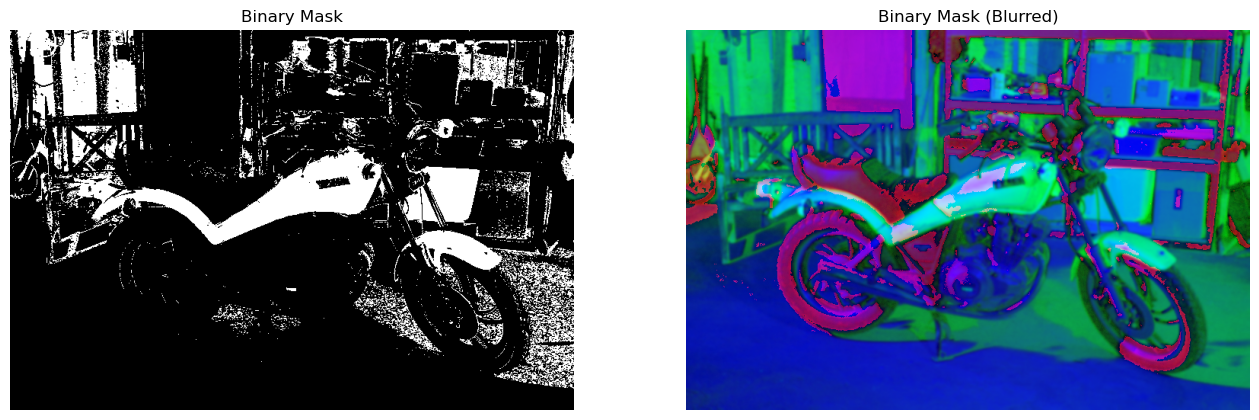

In [77]:
# Gaussian Filter를 적용하여 binary mask 생성 (커널 사이즈: 7x7)
motor_blur = cv2.GaussianBlur(motor, (7, 7), 0)

# RGB → HSV
mask_blur_hsv = cv2.cvtColor(motor_blur, cv2.COLOR_RGB2HSV)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(mask_hsv, cmap="gray")
plt.title("Binary Mask")

plt.subplot(1, 2, 2)
plt.imshow(mask_blur_hsv, cmap="gray")
plt.title("Binary Mask (Blurred)")

for ax in plt.gcf().axes:
    ax.axis("off")

plt.show()

너무 강하게 smoothing하면 정보 유실이 크기에 약하게만 smoothing filter를 적용합니다.

---

### F. Morphological Operation

그럼 남아있는 노이즈는 어떻게 처리할까요?

모폴로지 연산 (Morphological Operation)이란?
* 형태학적 연산
* Mask의 영역을 확대/축소
* Erosion(침식), Dilation(팽창), Opening(열기), Closing(닫기)

Erosion (침식)  vs.  Dilation (팽창):
* Erosion (침식)
  * Kernel 내 모든 픽셀이 1 (흰색)일 때만 중심 픽셀을 1 (흰색)으로 설정
  * AND
  * 흰색 영역 감소
  * 배경의 노이즈 제거
* Dilation (팽창)
  * Kernel 내 픽셀 하나라도 1 (흰색)이면 중심 픽셀을 1 (흰색)으로 설정
  * OR
  * 흰색 영역 확장
  * 내부의 검정 구멍과 내부의 끊어진 윤곽선 연결

Erosion (침식) vs. Dilation (팽창)

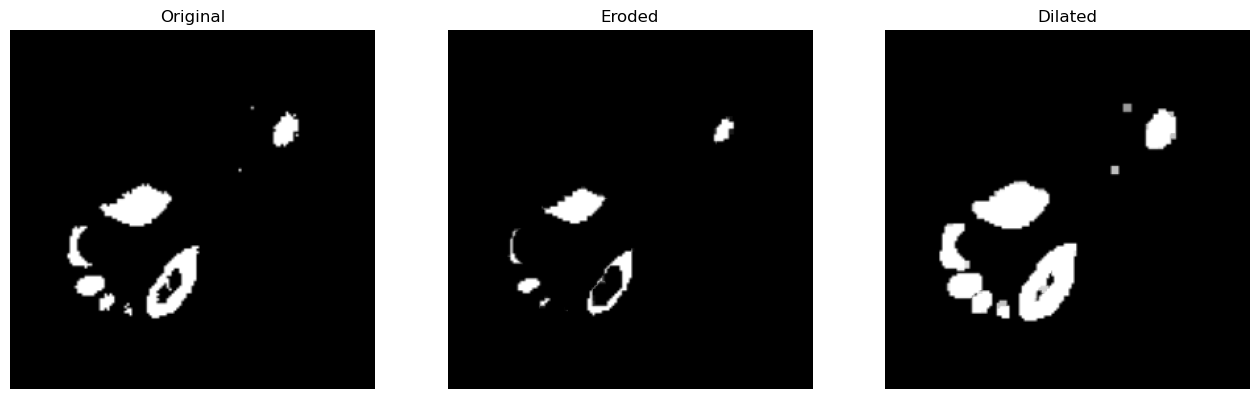

In [78]:
binmask_crop = cv2.imread('src/images/binmask_crop.PNG', cv2.IMREAD_GRAYSCALE)

binmask_crop_erode = cv2.erode(binmask_crop, None, iterations=2)
binmask_crop_dilate = cv2.dilate(binmask_crop, None, iterations=2)

plt.figure(figsize=(16,8))

plt.subplot(1,3,1), plt.imshow(binmask_crop, cmap="gray"), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(binmask_crop_erode, cmap="gray"), plt.title("Eroded")
plt.subplot(1,3,3), plt.imshow(binmask_crop_dilate, cmap="gray"), plt.title("Dilated")

for ax in plt.gcf().axes:
    ax.axis("off")

Opening (열기) vs. Closing (닫기)

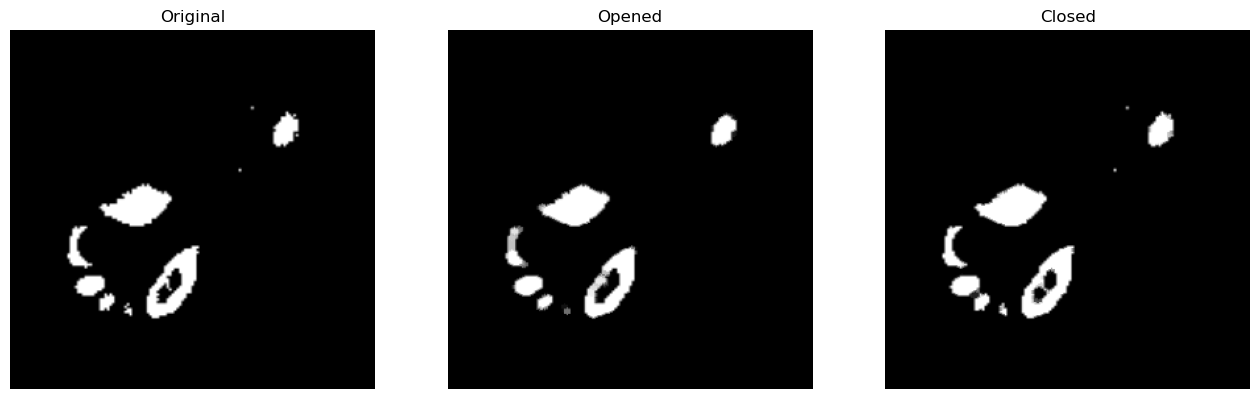

In [84]:
#kernel = np.ones((3, 3)) #네모네모
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)) # 타원형 

binmask_crop_opened = cv2.morphologyEx(binmask_crop, cv2.MORPH_OPEN, kernel)
binmask_crop_closed = cv2.morphologyEx(binmask_crop, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(16,8))

plt.subplot(1,3,1), plt.imshow(binmask_crop, cmap="gray"), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(binmask_crop_opened, cmap="gray"), plt.title("Opened")
plt.subplot(1,3,3), plt.imshow(binmask_crop_closed, cmap="gray"), plt.title("Closed")

for ax in plt.gcf().axes:
    ax.axis("off")

위에서 확인한 방식들을 활용하여 `skimage.data.stereo_motorcycle[0]` 이미지에서 깔끔하게 빨강 영역 검출을 시도해봅시다.

In [100]:
# TODO: 적절한 morphological opertaion을 사용하여 최적의 binary mask 생성
# TODO: subplot 3개 (원본 이진 마스크, blur 처리된 이진 마스크, 최종 마스크) 생성
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)) 


binmask_crop_opened = cv2.morphologyEx(motor_blur_hsv, cv2.MORPH_OPEN, kernel)
plt.figure(figsize=(16,8))

plt.subplot(1,3,1), plt.imshow(motor, cmap="gray"), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(motor_blur, cmap="gray"), plt.title("blur")
plt.subplot(1,3,3), plt.imshow(binmask_crop_opened, cmap="gray"), plt.title("final_binmask")

for ax in plt.gcf().axes:
    ax.axis("off")

NameError: name 'motor_blur_hsv' is not defined

---

### G. Image Enhancement

Image Enhancement란?
* Color segmentation은 조명 오염에 취약
* 대비를 강화하여 원하는 영역 추출
* LAB 색공간 사용

우선 조명 오염에 영향을 받은 이미지를 확인해봅시다.

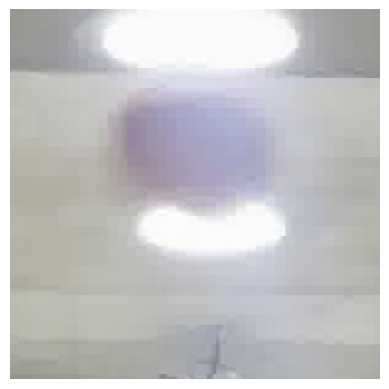

In [81]:
basketball = cv2.imread('src/images/basketball_crop.jpg')
basketball_rgb = cv2.cvtColor(basketball, cv2.COLOR_BGR2RGB)

plt.imshow(basketball_rgb)
plt.axis("off");

해당 이미지에 이전과 동일한 방식으로 color segmentation을 적용하여 binary mask를 생성해봅시다.

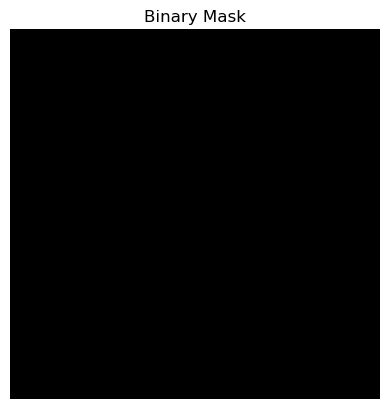

In [104]:
# TODO: 이미지를 HSV 색공간으로 변환
basketball_hsv = cv2.cvtColor(basketball_rgb, cv2.COLOR_RGB2HSV)

# TODO: lower_orange_hsv, upper_orange_hsv 배열 생성 (농구공 Hue는 대략 5~25, S와 V 범위는 시도)
lower_orange_hsv = np.array([5, 100, 100])
upper_orange_hsv = np.array([255, 255, 255])

# TODO: HSV mask 생성
mask_hsv = cv2.inRange(basketball_hsv, lower_orange_hsv, upper_orange_hsv)

plt.imshow(mask_hsv, cmap="gray"), plt.title("Binary Mask")
plt.axis("off");

정확한 HSV 범위를 알 수 없으니, 슬라이더를 사용하여 시도해봅시다.

In [ ]:
def update_mask(
    h_low, h_high,
    s_low, s_high,
    v_low, v_high
):
    lower_orange_hsv = np.array([h_low, s_low, v_low])
    upper_orange_hsv = np.array([h_high, s_high, v_high])

    mask_hsv = cv2.inRange(basketball_hsv, lower_orange_hsv, upper_orange_hsv)

    plt.figure(figsize=(12,8))

    plt.subplot(1,2,1), plt.imshow(basketball), plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2), plt.imshow(mask_hsv, cmap="gray")
    plt.title(f"H:{h_low}-{h_high}, S:{s_low}-{s_high}, V:{v_low}-{v_high}")
    plt.axis("off")

    plt.show()


interact(
    update_mask,
    h_low=(0, 179, 1),
    h_high=(0, 179, 1),
    s_low=(0, 255, 5),
    s_high=(0, 255, 5),
    v_low=(0, 255, 5),
    v_high=(0, 255, 5)
);

interactive(children=(IntSlider(value=89, description='h_low', max=179), IntSlider(value=89, description='h_hi…

조명 오염이 매우 심하여, 아무리 시도해도 농구공 영역을 추출하기가 어렵습니다.

그러므로 HSV 색공간 대신 LAB 색공간으로 변환하여 시도해봅시다.

LAB 색공간:
* 대립색 이론 (Opponent-Process Theory)를 기반으로 한 색공간
* L* (Lightness)
  * 인간의 눈이 체감하는 밝기 (지각 밝기)
  * 0 ~ 100 (어두움 ~ 밝음)
* a*
  * -128 ~ 127 (초록 ~ 빨강)
* b*
  * -128 ~ 127 (파랑 ~ 노랑)

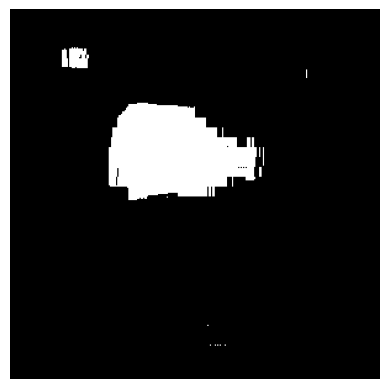

In [105]:
lab = cv2.cvtColor(basketball, cv2.COLOR_BGR2LAB)

lower_orange_lab = np.array([ 70, 130,  70])
upper_orange_lab = np.array([180, 230, 185])

mask_lab = cv2.inRange(lab, lower_orange_lab, upper_orange_lab)

plt.imshow(mask_lab, cmap="gray")
plt.axis("off");

LAB 기반 color segmentation은 조명 오염에도 불구하고 농구공 영역이 어느 정도 추출되는 것을 확인했습니다.

원본 사진과 합쳐 확인해봅시다.

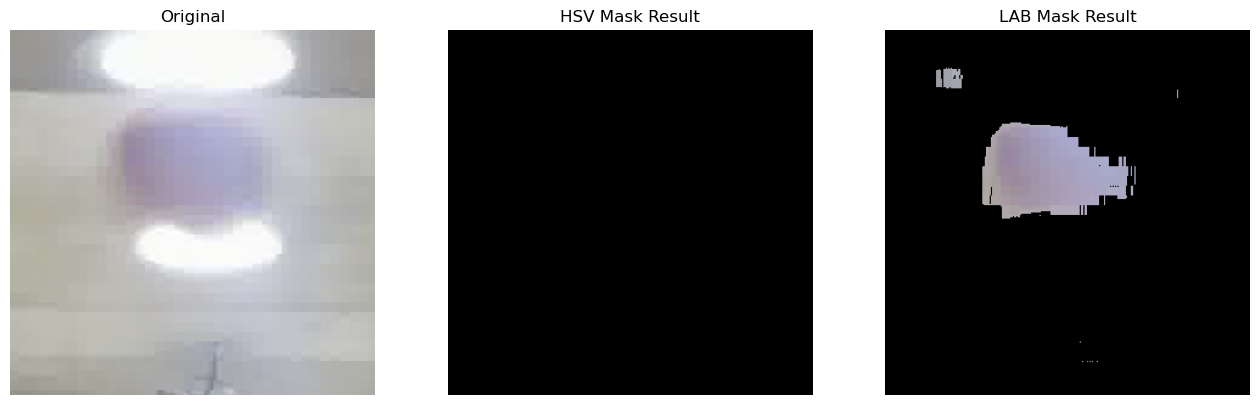

In [107]:
result_hsv = cv2.bitwise_and(basketball_rgb, basketball_rgb, mask=mask_hsv)
result_lab = cv2.bitwise_and(basketball_rgb, basketball_rgb, mask=mask_lab)

plt.figure(figsize=(16,8))
plt.subplot(1,3,1), plt.imshow(basketball_rgb), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(result_hsv), plt.title("HSV Mask Result")
plt.subplot(1,3,3), plt.imshow(result_lab), plt.title("LAB Mask Result")

for ax in plt.gcf().axes:
    ax.axis("off")

원하는 영역을 부분적으로 추출하였으나, 조금만 더 욕심내 볼까요?

LAB 기반 color segmentation과 더불어 CLAHE 기법을 적용해봅시다.

CLAHE (Contrast Limited Adaptive Histogram Equalization):
* “대비 제한 적응형 히스토그램 평활화”
* 이미지를 작은 영역으로 나누어 국소적인 대비 향상
* 노이즈가 과도하게 증폭되지 않도록 대비 상한선을 제한

CLAHE (Contrast Limited Adaptive Histogram Equalization) 발전 과정:
1. **Histogram Equalization**
   * 이미지 전체 밝기 분포 (히스토그램) 분석
   * 최소/최대 밝기에 맞춰 재분포
   * 이미지 전체를 일관적으로 처리
   * 특정 영역만 너무 밝거나 어두워지는 현상
2. **Adaptive** Histogram Equalization
   * 이미지를 격자로 분리 후 개별적으로 평탄화
   * 단색 구역의 노이즈 대비가 극대화되는 현상
3. **Contrast Limited** Adaptive Histogram Equalization
   * 히스토그램의 높이 (빈도수)가 제한을 초과하면 잘라냄
   * 단색 영역에서도 과도하지 않은 명암비

이제 CLAHE를 적용하여 명암 강화를 해봅시다.

In [ ]:
cat = skimage.data.chelsea()

plt.imshow(cat)
plt.axis("off");

이 고양이의 주황색 털을 추출해 보려고 합니다.

하지만 문제가 있습니다. 옅은 주황색과 진한 주황색 털이 저희가 원하는 "주황색"과 너무나도 비슷합니다.

우선 이미지 명암 강화 없이 color segmentation을 확인해봅시다.

In [ ]:
lower_orange_fur_hsv = np.array([12,  50,  50])
upper_orange_fur_hsv = np.array([38, 230, 230])

# TODO: 이미지를 HSV 색공간으로 변환
cat_hsv = ...

# TODO: 이진 마스크 생성
cat_mask = ...

# TODO: 이미지 출력

뭔가 디테일이 많이 부족한 모습입니다.

이번엔 CLAHE를 사용하여 대비를 강화해봅시다.

In [ ]:
# TODO: 이미지를 LAB 색공간으로 변환
cat_lab = ...

# TODO: 각 채널을 분리
l, a, b = ...

# CLAHE 생성 (clip 제한 2.0, 타일 크기 8x8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# L (Lightness) 강화
enhanced_l = clahe.apply(l)
enhanced_lab = cv2.merge((enhanced_l, a, b))

# TODO: LAB에서 HSV 색공간으로 바로 변환을 할 수 없으므로, RGB로 변환 후 HSV로 변환
enhanced_rgb = ...
enhanced_hsv = ...

# TODO: 강화된 이미지를 사용하여 이진 마스크 생성 (강화 전과 동일한 lower/upper HSV range 사용)
enhanced_cat_mask = ...

plt.figure(figsize=(16,10))
plt.subplot(2,2,1), plt.imshow(cat), plt.title("Original Image")
plt.subplot(2,2,2), plt.imshow(enhanced_rgb), plt.title("LAB (CLAHE) Enhanced Image")
plt.subplot(2,2,3), plt.imshow(cat_mask, cmap="gray"), plt.title("Binary Mask")
plt.subplot(2,2,4), plt.imshow(enhanced_cat_mask, cmap="gray"), plt.title("LAB (CLAHE) Enhanced Binary Mask")

for ax in plt.gcf().axes:
    ax.axis("off")

CLAHE 적용으로 명도 대비를 높이면, binary mask 생성 시 원하는 색상을 훨씬 더 명확하게 추출할 수 있습니다.

보다 더 정교한 결과를 위해서는 `skimage`의 `exposure.equalize_adapthist()` 함수를 사용하여 CLAHE를 적용할 수 있습니다.

In [ ]:
from skimage import color, exposure

cat = skimage.data.chelsea()

lower_orange_fur_hsv = np.array([12,  50,  50])
upper_orange_fur_hsv = np.array([38, 230, 230])
lower_orange_fur_hsv = lower_orange_fur_hsv / 255.
upper_orange_fur_hsv = upper_orange_fur_hsv / 255.

hsv_cat = color.rgb2hsv(cat)

mask_normal = (
    (hsv_cat[:, :, 0] >= lower_orange_fur_hsv[0]) & (hsv_cat[:, :, 0] <= upper_orange_fur_hsv[0]) &
    (hsv_cat[:, :, 1] >= lower_orange_fur_hsv[1]) & (hsv_cat[:, :, 1] <= upper_orange_fur_hsv[1]) &
    (hsv_cat[:, :, 2] >= lower_orange_fur_hsv[2]) & (hsv_cat[:, :, 2] <= upper_orange_fur_hsv[2])
)

lab = color.rgb2lab(cat)

l_channel = lab[:, :, 0] / 100.0
l_enhanced = exposure.equalize_adapthist(
    l_channel,
    kernel_size=32,
    clip_limit=0.02
)
lab[:, :, 0] = l_enhanced * 100.0

rgb_enhanced = (color.lab2rgb(lab) * 255).astype(np.uint8)
hsv_enhanced = color.rgb2hsv(rgb_enhanced)

mask_enhanced = (
    (hsv_enhanced[:, :, 0] >= lower_orange_fur_hsv[0]) & (hsv_enhanced[:, :, 0] <= upper_orange_fur_hsv[0]) &
    (hsv_enhanced[:, :, 1] >= lower_orange_fur_hsv[1]) & (hsv_enhanced[:, :, 1] <= upper_orange_fur_hsv[1]) &
    (hsv_enhanced[:, :, 2] >= lower_orange_fur_hsv[2]) & (hsv_enhanced[:, :, 2] <= upper_orange_fur_hsv[2])
)

plt.figure(figsize=(16,10))
plt.subplot(2,2,1), plt.imshow(cat), plt.title("Original Image")
plt.subplot(2,2,2), plt.imshow(rgb_enhanced), plt.title("LAB (CLAHE) Enhanced Image")
plt.subplot(2,2,3), plt.imshow(mask_normal, cmap="gray"), plt.title("Binary Mask")
plt.subplot(2,2,4), plt.imshow(mask_enhanced, cmap="gray"), plt.title("LAB (CLAHE) Enhanced Binary Mask")

for ax in plt.gcf().axes:
    ax.axis("off")

이제 CLAHE를 사용하여 이전에 시도했던 조명 오염이 강한 농구공 이미지를 강화해봅시다.

In [ ]:
lower_basketball_lab = np.array([70, 130, 70])
upper_basketball_lab = np.array([180, 230, 185])

basketball = cv2.imread('src/images/basketball_crop.jpg')

# TODO: LAB 색공간으로 변환
basketball_lab = ...

# TODO: 각 채널 분리
l, a, b = ...

# TODO: CLAHE 생성 (clipLimit은 3.0, tileGridSize는 8x8로 설정)
clahe = ...

# TODO: L 채널에 CLAHE 적용 후 강화된 이미지 생성
l_clahe_enhanced = ...
basketball_enhanced_lab = ...

# TODO: 강화된 이미지로 binary mask 생성
mask_enhanced = ...

# TODO: 강화된 이미지를 RGB로 변환 후 마스크를 통해 이미지 내 관심 영역만 추출
basketball_enhanced_rgb = ...
final_result = cv2.bitwise_and(...)

plt.figure(figsize=(16,8))
plt.subplot(1,3,1), plt.imshow(basketball_rgb), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(result_lab), plt.title("LAB Segmentation Result")
plt.subplot(1,3,3), plt.imshow(final_result), plt.title("LAB (CLAHE) Enhanced Segmentation Result")

for ax in plt.gcf().axes:
    ax.axis("off")

CLAHE를 적용하여 기존 LAB 색 공간 color segmentation보다 농구공 영역이 더욱 정확하게 추출되는 것을 확인했습니다.

하지만 여전히 농구공 외에 불필요한 영역도 함께 추출되는 한계가 있습니다.

그렇다면 오직 농구공 영역만 정밀하게 검출하려면 어떻게 해야 할까요?

---

### H. Contour Detection

외곽선 (Contour)이란?
* binary mask에서 연결된 영역의 외곽선
* 연결된 영역이기에 적절한 morphological operation 중요

우선 최종 생성된 농구공 mask에 morphological operation을 적용하여
i) 미세한 노이즈를 없애주거나 (opening)
ii) 빈 공간을 채워 끊어진 영역들을 연결시켜 줍시다 (closing).

오토바이 이미지로 한번 contour detection을 시도해봅시다.

우선 이미지에 약한 blur를 적용한 뒤 binary mask를 생성합니다.

그 다음, morphological operation으로 mask를 한층 더 깔끔하게 수정합니다.

In [ ]:
# Gaussin blur 적용
motor_blur = cv2.GaussianBlur(motor, (7, 7), 0)

# HSV로 변환
motor_blur_hsv = cv2.cvtColor(motor_blur, cv2.COLOR_RGB2HSV)

# 빨간색 추출하여 binary mask 생성
motor_mask1 = cv2.inRange(motor_blur_hsv, red_lower1, red_upper1)
motor_mask2 = cv2.inRange(motor_blur_hsv, red_lower2, red_upper2)
motor_mask = cv2.bitwise_or(motor_mask1, motor_mask2)

plt.figure(figsize=(16,8))

plt.subplot(1,2,1), plt.imshow(motor), plt.title("Original Image")
plt.subplot(1,2,2), plt.imshow(motor_mask, cmap="gray"), plt.title("Binary Mask (Blurred)")

for ax in plt.gcf().axes:
    ax.axis("off")

In [ ]:
# kernel = np.ones((5, 5), np.uint8)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

motor_mask_opened = cv2.morphologyEx(motor_mask, cv2.MORPH_OPEN, kernel)
motor_mask_closed = cv2.morphologyEx(motor_mask, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(16,8))
plt.subplot(1,3,1), plt.imshow(motor_mask, cmap="gray"), plt.title("Binary Mask")
plt.subplot(1,3,2), plt.imshow(motor_mask_opened, cmap="gray"), plt.title("Mask after Opening")
plt.subplot(1,3,3), plt.imshow(motor_mask_closed, cmap="gray"), plt.title("Mask after Closing")

for ax in plt.gcf().axes:
    ax.axis("off")

Opening을 적용한 결과가 오토바이의 외곽선을 추출하기에 좋아보입니다.

Closing은 우측 하단에 바닥 그림자가 더욱 커져 자칫 원치 않는 영역이 더욱 강조가 될 우려가 있습니다.

Opening의 결과가 좋아 보이기에 `iterations` 파라미터를 사용하여 여러번 적용해봅시다.

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

motor_mask_opened1 = cv2.morphologyEx(motor_mask, cv2.MORPH_OPEN, kernel)
motor_mask_opened2 = cv2.morphologyEx(motor_mask, cv2.MORPH_OPEN, kernel, iterations=2)
motor_mask_opened3 = cv2.morphologyEx(motor_mask, cv2.MORPH_OPEN, kernel, iterations=3)

plt.figure(figsize=(16,8))
plt.subplot(2,3,2), plt.imshow(motor), plt.title("Original Image")
plt.subplot(2,3,4), plt.imshow(motor_mask_opened1, cmap="gray"), plt.title("iteration = 1")
plt.subplot(2,3,5), plt.imshow(motor_mask_opened2, cmap="gray"), plt.title("iteration = 2")
plt.subplot(2,3,6), plt.imshow(motor_mask_opened3, cmap="gray"), plt.title("iteration = 3")

for ax in plt.gcf().axes:
    ax.axis("off")

2번이 노이즈가 많이 제거되어 좋은 binary mask로 보입니다.

3번은 좌측에 오토바이 후미 영역이 너무 멀리 끊어져 있어 2번을 가지고 추가 작업이 효율적일 것 같습니다.

2번 결과물에 closing을 적용해봅시다.

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

motor_mask_closed1 = cv2.morphologyEx(motor_mask_opened2, cv2.MORPH_CLOSE, kernel)
motor_mask_closed2 = cv2.morphologyEx(motor_mask_opened2, cv2.MORPH_CLOSE, kernel, iterations=2)
motor_mask_closed3 = cv2.morphologyEx(motor_mask_opened2, cv2.MORPH_CLOSE, kernel, iterations=3)

plt.figure(figsize=(16,8))
plt.subplot(2,3,2), plt.imshow(motor_mask_opened2, cmap="gray"), plt.title("Opening x2")
plt.subplot(2,3,4), plt.imshow(motor_mask_closed1, cmap="gray"), plt.title("Opening x2 & Closing x1")
plt.subplot(2,3,5), plt.imshow(motor_mask_closed2, cmap="gray"), plt.title("Opening x2 & Closing x2")
plt.subplot(2,3,6), plt.imshow(motor_mask_closed3, cmap="gray"), plt.title("Opening x2 & Closing x3")

for ax in plt.gcf().axes:
    ax.axis("off")

3번이 깔끔하게 오토바이의 빨간 영역을 검출할 수 있을 것 같습니다.

Opening 2회, Closing 3회를 적용하여 최종 binary mask를 생성하였습니다.

자, 이제 binary mask 영역의 contour를 추출해봅시다.

In [ ]:
# 최종 binary mask
final_motor_mask = motor_mask_closed3

# Contour를 그릴 원본 이미지 copy
final_img = motor.copy()

# 컨투어 추출 (두 번째 반환값인 hierarchy는 바깥쪽 테두리만 검출하는 현재 방식상 무의미하기에 저장하지 않음)
contours, _ = cv2.findContours(
    final_motor_mask,        # binary mask
    cv2.RETR_EXTERNAL,       # 구멍 뚫린 객체의 바깥쪽 테두리만 검출
    cv2.CHAIN_APPROX_SIMPLE  # 직선 경로 위에 있는 픽셀 좌표 전체 대신 꼭짓점 좌표만 저장
)

if len(contours) > 0:
    # Binary mask를 반투명 초록색으로 overlay
    mask_color = np.zeros_like(final_img)
    mask_color[:, :, 1] = final_motor_mask
    alpha = 0.35
    final_img = cv2.addWeighted(final_img, 1.0, mask_color, alpha, 0)

    # Contour 그리기 (초록색 외곽선)
    cv2.drawContours(final_img, contours, -1, (0,255,0), 2)

plt.imshow(final_img)
plt.axis("off");

이진 마스크(Binary Mask) 및 윤곽선 검출(Contour Detection)을 수행하여 이미지의 빨간색 영역(반투명 초록색)과 해당 외곽선(진한 초록색)을 추출하였습니다.

하지만 저희가 원하는건 오직 오토바이의 빨간 영역이죠.

그러기 위해서는 검출된 윤곽선 중 면적이 가장 크거나 둘레가 가장 긴 외곽선을 최종 선택합니다.

일반적으로 노이즈 및 불필요한 영역은 상대적으로 작은 면적을 형성하기 때문입니다.

이전 단계에서 Morphological Operation을 신중히 적용한 목적 역시 주 영역의 연속성을 확보하여 윤곽선 면적을 최대화하기 위함이었습니다.

In [ ]:
# 최종 binary mask
final_motor_mask = motor_mask_closed3

# Contour를 그릴 원본 이미지 copy
final_img = motor.copy()

# 컨투어 추출 (두 번째 반환값인 hierarchy는 바깥쪽 테두리만 검출하는 현재 방식상 무의미하기에 저장하지 않음)
contours, _ = cv2.findContours(
    final_motor_mask,        # binary mask
    cv2.RETR_EXTERNAL,       # 구멍 뚫린 객체의 바깥쪽 테두리만 검출
    cv2.CHAIN_APPROX_SIMPLE  # 직선 경로 위에 있는 픽셀 좌표 전체 대신 꼭짓점 좌표만 저장
)

if len(contours) > 0:
    # 가장 큰 contour
    largest_contour = max(contours, key=cv2.contourArea)

    # 가장 큰 contour만 채운 binary mask 생성
    final_mask = np.zeros_like(final_motor_mask)
    cv2.drawContours(
        final_mask,
        [largest_contour],
        -1,
        255,
        thickness=cv2.FILLED
    )

    # 가장 큰 contour만 채운 binary mask를 반투명 초록색으로 overlay
    mask_color = np.zeros_like(final_img)
    mask_color[:, :, 1] = final_mask
    alpha = 0.35
    final_img = cv2.addWeighted(final_img, 1.0, mask_color, alpha, 0)

    # Contour 그리기 (초록색 외곽선)
    cv2.drawContours(final_img, [largest_contour], -1, (0,255,0), 2)

plt.imshow(final_img)
plt.axis("off");

이제 동일한 방법으로 농구공의 외곽선을 검출해봅시다.

우선 morphological operation부터 적용해봅시다.

In [ ]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

ball_mask_opened = cv2.morphologyEx(mask_enhanced, cv2.MORPH_OPEN, kernel)
ball_mask_closed = cv2.morphologyEx(mask_enhanced, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(16,8))
plt.subplot(1,3,1), plt.imshow(mask_enhanced, cmap="gray"), plt.title("Enhanced Mask")
plt.subplot(1,3,2), plt.imshow(ball_mask_opened, cmap="gray"), plt.title("Mask after Opening")
plt.subplot(1,3,3), plt.imshow(ball_mask_closed, cmap="gray"), plt.title("Mask after Closing")

for ax in plt.gcf().axes:
    ax.axis("off")

저희 binary mask에는 노이즈가 많기에 확실히 Opening을 거친 결과가 훨씬 깔끔해진 것을 볼 수 있습니다.

Morphological operation부터 외곽선 검출, 그리고 외곽선 선택까지 해봅시다.

In [ ]:
# TODO: Morphological operation을 적용하여 최종 binary mask 생성
# TODO: Binary mask로 외곽선 검출
# TODO: 최종 농구공 영역 및 외곽선 선택

이제 공의 중심 및 반지름을 찾아 그려봅시다.

최소 외접원 (Minimum Enclosing Circle):

“외곽선의 모든 점들을 포함하는 가장 작은 원”

In [ ]:
# TODO: 최종 binary mask
final_ball_mask = ...

# Contour 및 외접원을 그릴 원본 이미지 copy
final_img_enhanced = basketball_enhanced_rgb.copy()

if len(contours) > 0:
    # 가장 큰 contour
    largest_contour = max(contours, key=cv2.contourArea)

    # 가장 큰 contour만 채운 binary mask 생성
    largest_mask = np.zeros_like(final_ball_mask)
    cv2.drawContours(
        largest_mask,
        [largest_contour],
        -1,
        255,
        thickness=cv2.FILLED
    )

    # 가장 큰 contour만 채운 binary mask를 반투명 빨간색으로 overlay
    mask_color = np.zeros_like(final_img_enhanced)
    mask_color[:, :, 0] = largest_mask
    alpha = 0.15
    final_img_enhanced = cv2.addWeighted(final_img_enhanced, 1.0, mask_color, alpha, 0)

    # Contour 그리기 (빨간색 외곽선)
    cv2.drawContours(final_img_enhanced, [largest_contour], -1, (255,0,0), 2)

    # 최소 외접원 중심 및 반지름
    (x, y), radius = cv2.minEnclosingCircle(largest_contour)
    center_circle = (int(x), int(y))
    radius = int(radius)

    # 파란색 원
    cv2.circle(final_img_enhanced, center_circle, radius, (0,0,255), 3)
    cv2.circle(final_img_enhanced, center_circle, 5, (0,0,255), -1)

plt.figure(figsize=(16,8))
plt.subplot(1,2,1), plt.imshow(basketball_enhanced_rgb)
plt.subplot(1,2,2), plt.imshow(final_img_enhanced)

for ax in plt.gcf().axes:
    ax.axis("off")

무게중심 (Centroid):

"객체(Contour)의 픽셀 분포를 기반으로 계산한 기하학적 중심점(객체의 중심 좌표)"

무게중심  =  픽셀 가중치 합 / 전체 면적
$$
C_x = \frac{M_{10}}{M_{00}}, \qquad
C_y = \frac{M_{01}}{M_{00}}
$$

In [ ]:
# TODO: 최종 binary mask
final_ball_mask = ...

# Contour 및 무게중심 기준 원을 그릴 원본 이미지 copy
final_img_enhanced = basketball_enhanced_rgb.copy()

if len(contours) > 0:
    # 가장 큰 contour
    largest_contour = max(contours, key=cv2.contourArea)

    # 가장 큰 contour만 채운 binary mask 생성
    largest_mask = np.zeros_like(final_ball_mask)
    cv2.drawContours(
        largest_mask,
        [largest_contour],
        -1,
        255,
        thickness=cv2.FILLED
    )

    # 가장 큰 contour만 채운 binary mask를 반투명 빨간색으로 overlay
    mask_color = np.zeros_like(final_img_enhanced)
    mask_color[:, :, 0] = largest_mask
    alpha = 0.15
    final_img_enhanced = cv2.addWeighted(final_img_enhanced, 1.0, mask_color, alpha, 0)

    # Contour 그리기 (빨간색 외곽선)
    cv2.drawContours(final_img_enhanced, [largest_contour], -1, (255,0,0), 2)

    # Moments를 통해 무게중심 (Centroid) 산출
    M = cv2.moments(largest_contour)

    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = 0, 0

    centroid = (cX, cY)

    # 노란색 무게중심
    cv2.circle(final_img_enhanced, centroid, 5, (255,255,0), -1)

plt.figure(figsize=(16,8))
plt.subplot(1,2,1), plt.imshow(basketball_enhanced_rgb)
plt.subplot(1,2,2), plt.imshow(final_img_enhanced)

for ax in plt.gcf().axes:
    ax.axis("off")

무게중심을 산출하는 과정에서 반지름은 구할 수 없기에 최소 외접원 반지름과 함께 혼합하여 최종적인 공 영역을 예측할 수 있습니다.

In [ ]:
# TODO: 최종 binary mask
final_ball_mask = ...

# Contour 및 무게중심 기준 원을 그릴 원본 이미지 copy
final_img_enhanced = basketball_enhanced_rgb.copy()

if len(contours) > 0:
    # 가장 큰 contour
    largest_contour = max(contours, key=cv2.contourArea)

    # 가장 큰 contour만 채운 binary mask 생성
    largest_mask = np.zeros_like(final_ball_mask)
    cv2.drawContours(
        largest_mask,
        [largest_contour],
        -1,
        255,
        thickness=cv2.FILLED
    )

    # 가장 큰 contour만 채운 binary mask를 반투명 빨간색으로 overlay
    mask_color = np.zeros_like(final_img_enhanced)
    mask_color[:, :, 0] = largest_mask
    alpha = 0.15
    final_img_enhanced = cv2.addWeighted(final_img_enhanced, 1.0, mask_color, alpha, 0)

    # Contour 그리기 (빨간색 외곽선)
    cv2.drawContours(final_img_enhanced, [largest_contour], -1, (255,0,0), 2)

    # 최소 외접원 중심 및 반지름
    (x, y), radius = cv2.minEnclosingCircle(largest_contour)
    center_circle = (int(x), int(y))
    radius = int(radius)

    # Moments를 통해 무게중심 (Centroid) 산출
    M = cv2.moments(largest_contour)

    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = center_circle

    centroid = (cX, cY)

    # 노란색 무게중심 기반 원
    cv2.circle(final_img_enhanced, centroid, radius, (255,255,0), 3)
    cv2.circle(final_img_enhanced, centroid, 5, (255,255,0), -1)

plt.figure(figsize=(16,8))
plt.subplot(1,2,1), plt.imshow(basketball_enhanced_rgb)
plt.subplot(1,2,2), plt.imshow(final_img_enhanced)

for ax in plt.gcf().axes:
    ax.axis("off")

최소 외접원 vs. 무게중심 최종 비교

In [ ]:
# TODO: 최종 binary mask
final_ball_mask = ...

# Contour 및 무게중심 기준 원을 그릴 원본 이미지 copy
final_img_enhanced = basketball_enhanced_rgb.copy()

if len(contours) > 0:
    # 가장 큰 contour
    largest_contour = max(contours, key=cv2.contourArea)

    # 가장 큰 contour만 채운 binary mask 생성
    largest_mask = np.zeros_like(final_ball_mask)
    cv2.drawContours(
        largest_mask,
        [largest_contour],
        -1,
        255,
        thickness=cv2.FILLED
    )

    # 가장 큰 contour만 채운 binary mask를 반투명 빨간색으로 overlay
    mask_color = np.zeros_like(final_img_enhanced)
    mask_color[:, :, 0] = largest_mask
    alpha = 0.15
    final_img_enhanced = cv2.addWeighted(final_img_enhanced, 1.0, mask_color, alpha, 0)

    # Contour 그리기 (빨간색 외곽선)
    cv2.drawContours(final_img_enhanced, [largest_contour], -1, (255,0,0), 2)

    # 최소 외접원 중심 및 반지름
    (x, y), radius = cv2.minEnclosingCircle(largest_contour)
    center_circle = (int(x), int(y))
    radius = int(radius)

    # 파란색 최소 외접원
    cv2.circle(final_img_enhanced, center_circle, radius, (0,0,255), 3)
    cv2.circle(final_img_enhanced, center_circle, 5, (0,0,255), -1)

    # Moments를 통해 무게중심 (Centroid) 산출
    M = cv2.moments(largest_contour)

    if M["m00"] != 0:
        cX = int(M["m10"] / M["m00"])
        cY = int(M["m01"] / M["m00"])
    else:
        cX, cY = center_circle

    centroid = (cX, cY)

    # 노란색 무게중심 기반 원
    cv2.circle(final_img_enhanced, centroid, radius, (255,255,0), 3)
    cv2.circle(final_img_enhanced, centroid, 5, (255,255,0), -1)

plt.figure(figsize=(16,8))
plt.subplot(1,2,1), plt.imshow(basketball_enhanced_rgb)
plt.subplot(1,2,2), plt.imshow(final_img_enhanced)

for ax in plt.gcf().axes:
    ax.axis("off")

---

### I. Interest Point Extraction

특징점 추출 (Interest Point Extraction)이란?
* 이미지 내에서 정보량이 높은 주요 지점(특징점, Interest Point)을 찾는 과정
* 주변과 구별되는 중요한 위치 탐색
* 모서리, 코너 등 주변 픽셀과 다른 패턴을 가진 위치를 검출
* 추출된 특징점을 기반으로 이미지 간 비교 및 객체 추적 수행 가능
* 크기, 회전, 조명 변화에도 비교적 안정적인 추적 가능
* 대표적인 방법으로는 Harris Corner, SIFT, ORB 등

Harris Corner Detection 과정:
1. Sobel Filter 적용 → dx (x축 기울기), dy (y축 기울기), dxx (x축 변화율), dyy (y축 변화율), dxy (x-y축 변화율 상관관계)
2. Gaussian Filter 적용 (dxx, dyy, dxy)
3. Harris Response 계산
4. Response 값을 Thresholding
5. Thresholding 결과에 Non-Maximum Suppression 적용
6. 최종 코너 검출


Harris Corner Detection을 적용해봅시다.

우선 이미지를 불러옵시다.

In [ ]:
cam_img = skimage.data.camera()

plt.imshow(cam_img, cmap="gray")
plt.axis("off");

그 다음, `cv2.Sobel`와 `cv2.GaussianBlur` 함수를 사용하여 Harris Response를 계산합니다:
$$
Harris(\hat{M}) = \det(\hat{M})-\alpha\mathrm{trace}^2(\hat{M}) \approx G(I_x^2)G(I_y^2)-G(I_xI_y)^2-\alpha[G(I_x^2)+G(I_y^2)]^2
$$
$G$: Gaussian Filter
$I_x,I_y$: 이미지 미분값 (Sobel Filter)


In [ ]:
def harris(im, k=int(3), alpha=0.05):  # k = Gaussian filter의 kernel 크기
    # Sobel Filter를 사용하여 x와 y축의 미분값 계산
    dx = cv2.Sobel(im, -1, dx=1, dy=0)
    dy = cv2.Sobel(im, -1, dx=0, dy=1)

    # x-x, x-y and y-y 방향 미분값을 Gaussian blur 적용
    dxx = cv2.GaussianBlur(dx**2, (k,k), sigmaX=-1)
    dyy = cv2.GaussianBlur(dy**2, (k,k), sigmaX=-1)
    dxy = cv2.GaussianBlur(dx*dy, (k,k), sigmaX=-1)

    # Response function 계산
    return dxx * dyy - dxy**2 - alpha * (dxx + dyy)**2

Harris Response를 heatmap으로 시각화하면:

In [ ]:
har = harris(np.float32(cam_img), 11, 0.05)

plt.figure(figsize=(12,8))
plt.imshow(cam_img, cmap='gray')
plt.imshow(har, cmap='jet', alpha=0.75), plt.colorbar();

이제 Harris Response 이미지에서 코너를 검출해봅시다.

In [ ]:
# 이미지에서 local maxima 포인트들을 검출
def findLocalMaxima(im, threshold=50):
    # Thresholding
    points = np.argwhere(im > threshold)
    points = [(x,y) for y,x in points]

    # 주변 8개 픽셀들과 비교하여 local maxima 검출
    maxima = []
    for p in points:
        # 이미지의 가장자리는 스킵
        if p[0] == 0 or p[0] == im.shape[1]-1 or p[1] == 0 or p[1] == im.shape[0]-1:
           continue

        neighbors = im[p[1]-1:p[1]+2, p[0]-1:p[0]+2]
        if np.all(neighbors <= im[p[1],p[0]]):
            maxima.append(p)

    return np.array(maxima)

In [ ]:
harris_points = findLocalMaxima(har, 2e9)

plt.figure(figsize=(8,8))

plt.imshow(cam_img, cmap='gray')
plt.scatter(harris_points[:,0], harris_points[:,1], c='r', s=10)
plt.axis("off");

---

### J. 실시간 카메라 피드

#### $1)$ Jetson CSI 카메라 연결 및 동작 확인

먼저 시스템에 인식된 카메라 장치 파일(/dev/video0, /dev/video1 등)을 확인합니다.

```bash
ls /dev/video*
```

만약 `/dev/video*` 장치가 존재하지 않는다면, Jetson에서 카메라 인터페이스 설정이 활성화되어 있는지 확인해야 합니다. 아래 도구를 실행하여 CSI 카메라 설정을 활성화합니다.

```bash
sudo /opt/nvidia/jetson-io/jetson-io.py
```

활성화가 되었다면 재부팅 후 카메라 장치를 다시 확인합니다.

```bash
reboot
ls /dev/video*
```

터미널에 `/dev/video0` 혹은 `/dev/video1`이 출력된다면 정상적으로 카메라 장치가 인식이 되었다는 의미입니다.

실시간 카메라 피드를 확인해봅시다.

```bash
gst-launch-1.0 nvarguscamerasrc sensor-id=0 ! nvvidconv ! autovideosink
```

에러가 발생하며 카메라 영상 출력이 되지 않는다면 아래 명령어를 실행하고 다시 카메라 피드를 확인합시다.

```bash
sudo systemctl restart nvargus-daemon
```

카메라 영상이 확인이 된다면 다음으로 넘어가도록 합시다.

#### $2)$ 일반 Webcam의 실시간 카메라 피드 처리 방식

#### `cv2.VideoCapture()`:

```python
import cv2


cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()

    if not ret:
        break
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

    cv2.imshow("VideoCapture", frame)

cap.release()
cv2.destroyAllWindows()
```

#### `imutils.video.VideoStream()`:

```python
import cv2

import time
from imutils.video import VideoStream


vs = VideoStream(src=0).start()
time.sleep(1.0)

while True:
    frame = vs.read()

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

    cv2.imshow("VideoStream", frame)

vs.stop()
cv2.destroyAllWindows()
```

#### $3)$ Jetson CSI 카메라 GStreamer 파이프라인 테스트

#### `GStreamer`:

우선, 카메라가 지원하는 포멧을 확인합니다.

```bash
sudo apt install v4l-utils
v4l2-ctl --list-formats-ext -d /dev/video0
```

일반적인 USB 카메라의 경우 출력은 다음과 같이 나타납니다.

```text
MJPG
    1280x720
    30 fps
```

또는

```text
YUYV
    640x480
    30 fps
```

출력에 따라 사용할 파이프라인을 선택합니다.

카메라가 MJPEG를 지원할 경우:

```python
pipeline = (
    "v4l2src device=/dev/video0 ! "
    "image/jpeg,width=1280,height=720,framerate=30/1 ! "
    "jpegdec ! videoconvert ! video/x-raw,format=BGR ! "
    "queue leaky=downstream max-size-buffers=1 "
    "max-size-bytes=0 max-size-time=0 ! "
    "appsink drop=true max-buffers=1 sync=false"
)
```

카메라가 YUYV를 지원할 경우:

```python
pipeline = (
    "v4l2src device=/dev/video0 ! "
    "video/x-raw,format=YUY2,width=640,height=480,framerate=30/1 ! "
    "videoconvert ! video/x-raw,format=BGR ! "
    "queue leaky=downstream max-size-buffers=1 "
    "max-size-bytes=0 max-size-time=0 ! "
    "appsink drop=true max-buffers=1 sync=false"
)
```

하지만 Jetson의 CSI 카메라는 일반 USB 카메라와 동작 방식이 다릅니다.

CSI 카메라는 센서에서 출력되는 원본 Bayer 데이터를 ISP(Image Signal Processor)를 통해 변환해야 하며, 일반적으로 다음과 같은 형태로 표시됩니다.

```text
'RG10' (10-bit Bayer RGRG/GBGB)
    Size: Discrete 3280x2464
    Size: Discrete 1920x1080
    Size: Discrete 1640x1232
    Size: Discrete 1280x720
```

이 경우 MJPEG 또는 YUYV 파이프라인을 사용하는 것이 아니라, NVIDIA Argus 카메라 인터페이스를 사용하는 `nvarguscamerasrc`를 사용해야 합니다.

`nvarguscamerasrc`는 Jetson의 ISP를 이용하여 Bayer 센서 데이터를 자동으로 처리하고, OpenCV에서 사용할 수 있는 BGR 이미지로 변환합니다.

```python
pipeline = (
    "nvarguscamerasrc sensor-id=0 ! "
    "video/x-raw(memory:NVMM), width=1280, height=720, framerate=30/1 ! "
    "nvvidconv ! "
    "video/x-raw, format=BGRx ! "
    "videoconvert ! "
    "video/x-raw, format=BGR ! "
    "appsink"
)

# pipeline = (
#     "nvarguscamerasrc sensor-id=0 ! "
#     "video/x-raw(memory:NVMM), width=1280, height=720, framerate=30/1 ! "
#     "nvvidconv ! "
#     "video/x-raw, format=BGRx ! "
#     "videoconvert ! "
#     "video/x-raw, format=BGR ! "
#     "queue leaky=downstream max-size-buffers=1 ! "
#     "appsink drop=true max-buffers=1 sync=false"
# )
```

pipeline 선택 후 코드:

```python
cap = cv2.VideoCapture(pipeline, cv2.CAP_GSTREAMER)

while True:
    ret, frame = cap.read()

    if not ret:
        break
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

    cv2.imshow("VideoCapture with GStreamer", frame)

cap.release()
cv2.destroyAllWindows()
```

---

### K. 실시간 객체 검출

이제 앞선 실습에서 Color Segmentation을 활용해 이미지 속 원하는 색상 객체를 검출한 것과 동일하게 실시간 카메라 프레임 속 객체를 검출해봅시다.

기존과 동일한 방식을 사용하지만, 이제는 `while`문을 사용하여 매 프레임을 처리하여 출력합니다.

```python
# TODO: 배운 기술(이미지 전처리, 특징 추출)을 활용하여 실시간으로 객체를 검출

# 초록 LAB lower/upper range
green_lower = np.array([30, 60, 90], dtype=np.uint8)
green_upper = np.array([230, 115, 180], dtype=np.uint8)

# TODO: 각 프레임 이미지를 전처리
# TODO: Color Segmentation으로 Binary Mask 생성
# TODO: Morphological Operation을 적용하여 객체 영역 추출
# TODO: 객체의 중심과 반지름을 구해 프레임 위에 overlay
```

---

### L. 실시간 객체 추적

Kalman Filter (칼만 필터)란?
* 노이즈가 포함된 측정값으로부터 실제 상태(위치, 속도 등)를 추정하는 알고리즘
* 예측(Prediction)과 보정(Update) 과정을 반복하여 추정값을 지속적으로 개선
* 센서 오차나 일시적인 측정 실패가 있어도 안정적인 추적 가능
* 로봇 제어, 자율주행, 객체 추적 등 다양한 실시간 시스템에 활용

한번 직접 Kalman Filter 함수를 만들어봅시다.

우선 역행렬 (inverse matrix)를 만들기 위해 NumPy의 `linalg.inv`를 import 합니다.

Inverse는 `inv(_)`, transpose는 `_.transpose()`, dot product는 `_.dot(_)` 함수를 사용합니다.

```python
from numpy.linalg import inv
```

Kalman Filter 함수 및 변수 정의:

```python
def KalmanFilter(mu_prev, sigma_prev, z):
    mu_bar = A_t.dot(mu_prev)
    sigma_bar = A_t.dot(sigma_prev).dot(A_t.transpose()) + R_t
    if z is None:
        return mu_bar, sigma_bar
    else:
        K_t = sigma_bar.dot(C_t.transpose()).dot(inv(C_t.dot(sigma_bar).dot(C_t.transpose()) + Q_t))
        mu = mu_bar + K_t.dot(z - C_t.dot(mu_bar))
        sigma = (np.identity(2) - K_t.dot(C_t)).dot(sigma_bar)
        return mu, sigma


# Kalman filter 변수 정의
A_t = np.array([[1, 1], [0, 1]])
G = np.array([[0.5], [1]])
R_t = G.dot(G.transpose())
C_t = np.array([[1, 0]])
Q_t = np.array([[1]])
mu_t = np.array([[0, 0], [0, 0]])
sigma_t = np.array([[0, 0], [0, 0]])
```

Kalman Filter 함수를 적용해봅시다.

```python
# TODO: Kalman Filter를 활용하여 객체 추적

# TODO: 탐지된 객체의 중심과 반지름을 구해 프레임 위에 overlay
# TODO: 예측된 객체의 중심과 반지름을 구해 프레임 위에 다른 색으로 overlay

contour_lst, _ = cv2.findContours(...)

# 객체 최초 검출 여부 확인용 boolean
found = False

while True:
    frame = ...

    if len(contour_lst) > 0:
        # 가장 큰 contour 선택
        contour = ...
        # 최소 외접원 반지름
        radius = ...
        # 무게중심
        center = ...

        # 검출된 객체에 파란 원 overlay
        cv2.circle(frame, center, int(radius), ...)
        cv2.circle(frame, center, ...)

        # 객체 최초 검출
        if not found:
            found = True

    # 최초 검출 이후 Kalman Filter 적용
    # 측정값 사용 (visible) -> Prediction & Update
    if found and (len(contour_lst) > 0):
        mu_t, sigma_t = KalmanFilter(mu_t, sigma_t, np.array([list(center)]))
        x_bel, y_bel = mu_t[0][0], mu_t[0][1]

    # 측정값 미사용 (occluded) -> Prediction
    elif found and (len(contour_lst) <= 0):
        mu_t, sigma_t = KalmanFilter(mu_t, sigma_t, None)
        x_bel, y_bel = mu_t[0][0], mu_t[0][1]

    # 예측한 객체 위치에 노란 원 overlay
    cv2.circle(frame, (int(x_bel), int(y_bel)), int(radius),...)
    cv2.circle(frame, (int(x_bel), int(y_bel)), ...)
```

직접 정의한 Kalman Filter 대신 OpenCV의 `cv2.KalmanFilter` 함수를 사용하여 더욱 부드러운 예측이 가능합니다.

```python
# TODO: OpenCV의 Kalman Filter 함수를 활용하여 객체 추적

# --------------- OpenCV Kalman Filter 설정 ---------------
# 상태 벡터: [x, y, vx, vy]
# 측정 벡터: [x, y]
kalman = cv2.KalmanFilter(4, 2)

# Transition Matrix (상태 전이 행렬)
kalman.transitionMatrix = np.array(
    [
        [1, 0, 1, 0],
        [0, 1, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
    ],
    dtype=np.float32,
)

# Measurement Matrix (측정 행렬)
# 측정값으로부터 x, y만 관측
kalman.measurementMatrix = np.array(
    [
        [1, 0, 0, 0],
        [0, 1, 0, 0],
    ],
    dtype=np.float32,
)

# Process Noise Covariance Matrix (프로세스 노이즈 공분산)
# 값이 클수록 모델 예측보다 측정값 변화에 더 유연하게 반응
kalman.processNoiseCov = np.array(
    [
        [1e-2, 0, 0, 0],
        [0, 1e-2, 0, 0],
        [0, 0, 5e-2, 0],
        [0, 0, 0, 5e-2],
    ],
    dtype=np.float32,
)

# Measurement Noise Covariance Matrix (측정 노이즈 공분산)
# 값이 클수록 측정값을 덜 신뢰하고 예측값을 더 신뢰
kalman.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1.0

# Posteriori Error Covariance Matrix (초기 추정 오차 공분산)
kalman.errorCovPost = np.eye(4, dtype=np.float32)

# -------------------------------------------------------

contour_lst, _ = cv2.findContours(...)

# 객체 최초 검출 여부 확인용 boolean
found = False

while True:
    frame = ...

    if len(contour_lst) > 0:
        # 가장 큰 contour 선택
        contour = ...
        # 최소 외접원 반지름
        radius = ...
        # 무게중심
        center = ...

        # 검출된 객체에 파란 원 overlay
        cv2.circle(frame, center, int(radius), ...)
        cv2.circle(frame, center, ...)

        # 객체 최초 검출 (최초 a priori state 저장)
        if not found:
            kalman.statePre = np.array([[center[0]], [center[1]], [0.0], [0.0]], dtype=np.float32)
            found = True

    # 최초 검출 이후 Kalman Filter 적용
        # 측정값 사용 (visible) -> Prediction & Update
        if found and (len(contour_lst) > 0):
            predicted_state = kalman.predict()   # prediction
            corrected_state = kalman.correct(z)  # update
            x_bel = corrected_state[0, 0]
            y_bel = corrected_state[1, 0]

        # 측정값 미사용 (occluded) -> Prediction
        elif found and (len(contour_lst) <= 0):
            predicted_state = kalman.predict()   # prediction (update X)
            x_bel = predicted_state[0, 0]
            y_bel = predicted_state[1, 0]

    # 예측한 객체 위치에 노란 원 overlay
    cv2.circle(frame, (int(x_bel), int(y_bel)), int(radius), ...)
    cv2.circle(frame, (int(x_bel), int(y_bel)), ...)
```

이로써 객체를 탐지와 함께 추적 및 예측도 할 수 있게 되었습니다.

Kalman Filter를 사용하여, 선형적으로 객체의 위치를 예측하여 조명 오염, 센서 불량, 객체 가려짐 등 상황에서도 끊임 없는 추적을 할 수 있으며, 몇 초 뒤의 객체 위치도 대략적으로 예측이 가능합니다.

---

### M. MediaPipe 실시간 신체 인식

신체(자세, 손, 얼굴) 인식/추적을 하기 위한 라이브러리인 MediaPipe를 우선 설치합니다.

```bash
pip install --no-deps mediapipe
pip install absl-py flatbuffers sounddevice
```

`MediaPipe`에서 사용하는 모델도 설치해줍시다.

```bash
wget https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task -O src/models/MediaPipe/hand_landmarker.task
wget https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/latest/pose_landmarker_full.task -o src/models/MediaPipe/pose_landmarker_full.task
```

이제 아래 코드를 한번 새 .py 파일에 복사하여 시도해봅시다.

```python
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


base_option = python.BaseOptions(model_asset_path="src/models/MediaPipe/hand_landmarker.task")  # 모델 경로 지정하는 옵션
options = vision.HandLandmarkerOptions(base_options=base_option, num_hands=2)                   # 모델 경로와 최대 손 개수 지정
hand_detector = vision.HandLandmarker.create_from_options(options)                              # 해당 옵션으로 손 검출하는 객체 생성
connections = vision.HandLandmarksConnections.HAND_CONNECTIONS                                  # 각 landmark를 잇는 연결선 정보
finger_tips = (4, 8, 12, 16, 20)                                                                # 손가락 끝 landmark의 index

pipeline = (
    "nvarguscamerasrc sensor-id=0 ! "
    "video/x-raw(memory:NVMM), width=1280, height=720, framerate=30/1 ! "
    "nvvidconv ! "
    "video/x-raw, format=BGRx ! "
    "videoconvert ! "
    "video/x-raw, format=BGR ! "
    "queue leaky=downstream max-size-buffers=1 ! "
    "appsink drop=true max-buffers=1 sync=false"
)

cap = cv2.VideoCapture(pipeline, cv2.CAP_GSTREAMER)

while True:
    ret, frame = cap.read()

    if not ret:
        break
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

    # 이미지 좌우 반전 및 RGB로 색공간 변환 (전처리)
    frame = cv2.flip(frame, 0)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 프레임 내 손 탐지
    result = hand_detector.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))

    # 화면 좌측 상단에 텍스트 생성 (손 개수, 왼손/오른손/양손 여부)
    labels = ["Left" if h[0].category_name == "Right" else "Right" for h in result.handedness]
    cv2.putText(frame, f"Hands: {len(result.hand_landmarks)}", (20,35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)
    cv2.putText(frame, " / ".join(labels), (20,70), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)

    # 탐지 결과의 각 손마다 선과 점 그리기
    for hand in result.hand_landmarks:
        h, w = frame.shape[:2]  # 프레임 높이와 너비
        points = [(int(p.x * w), int(p.y * h)) for p in hand]  # 프레임 높이와 너비 길이 기준 각 landmark 좌표

        # landmark를 연결하는 선 (skeleton) 그리기
        for c in connections:
            cv2.line(frame, points[c.start], points[c.end], (0,255,0), 2)

        # 각 관절 (landmark)에 점 그리기 (손가락 끝은 빨간 점, 그 외에는 파란 점)
        for i, point in enumerate(points):
            color = (0,0,255) if i in finger_tips else (255,0,0)
            cv2.circle(frame, point, 6 if i in finger_tips else 4, color, -1)

    cv2.imshow("MediaPipe Hand Detection", frame)

hand_detector.close()
cap.release()
cv2.destroyAllWindows()
```

Rule-based (규칙 기반) 시스템으로 펼쳐진 손가락 개수 계산:

```python
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


# 중간 점 기준으로 각도 계산하는 함수
def calculate_angle(p1, p2, p3):
    vector1 = np.array([p1.x - p2.x, p1.y - p2.y, p1.z - p2.z])
    vector2 = np.array([p3.x - p2.x, p3.y - p2.y, p3.z - p2.z])

    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)

    if magnitude1 == 0 or magnitude2 == 0:
        return 0.0

    cosine = np.dot(vector1, vector2) / (magnitude1 * magnitude2)
    cosine = np.clip(cosine, -1.0, 1.0)

    return np.degrees(np.arccos(cosine))


base_option = python.BaseOptions(model_asset_path="src/models/MediaPipe/hand_landmarker.task")  # 모델 경로 지정하는 옵션
options = vision.HandLandmarkerOptions(base_options=base_option, num_hands=2)                   # 모델 경로와 최대 손 개수 지정
hand_detector = vision.HandLandmarker.create_from_options(options)                              # 해당 옵션으로 손 검출하는 객체 생성
connections = vision.HandLandmarksConnections.HAND_CONNECTIONS                                  # 각 landmark를 잇는 연결선 정보

finger_tips = (4, 8, 12, 16, 20)  # 손가락 끝 landmark의 index
angle_threshold = 160             # 손가락 펼쳐짐 여부 판단 각도 임계값

# 각 손가락의 각도를 계산할 landmark index
finger_angle_points = (
    (1, 2, 3),      # 엄지: 2번 중심
    (5, 6, 7),      # 검지: 6번 중심
    (9, 10, 11),    # 중지: 10번 중심
    (13, 14, 15),   # 약지: 14번 중심
    (17, 18, 19),   # 소지: 18번 중심
)

pipeline = (
    "nvarguscamerasrc sensor-id=0 ! "
    "video/x-raw(memory:NVMM), width=1280, height=720, framerate=30/1 ! "
    "nvvidconv ! "
    "video/x-raw, format=BGRx ! "
    "videoconvert ! "
    "video/x-raw, format=BGR ! "
    "queue leaky=downstream max-size-buffers=1 ! "
    "appsink drop=true max-buffers=1 sync=false"
)

cap = cv2.VideoCapture(pipeline, cv2.CAP_GSTREAMER)

while True:
    ret, frame = cap.read()

    if not ret:
        break
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

    # 프레임 높이와 너비
    h, w = frame.shape[:2]

    # 이미지 좌우 반전 및 RGB로 색공간 변환 (전처리)
    frame = cv2.flip(frame, 0)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # 프레임 내 손 탐지
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = hand_detector.detect(mp_image)

    # 좌우 반전된 화면을 기준으로 왼손과 오른손 정보 변경
    labels = ["Left" if handedness[0].category_name == "Right" else "Right" for handedness in result.handedness]

    # 감지된 모든 손에서 펼쳐진 손가락 개수 계산
    total_finger_count = 0
    for hand in result.hand_landmarks:
        for point1_idx, point2_idx, point3_idx in finger_angle_points:
            angle = calculate_angle(
                hand[point1_idx],
                hand[point2_idx],
                hand[point3_idx],
            )

            if angle >= angle_threshold:
                total_finger_count += 1

    # 화면 좌측 상단에 손 개수와 펼친 손가락 개수 표시
    cv2.putText(frame, f"Hands: {len(result.hand_landmarks)}", (20,35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)
    cv2.putText(frame, f"Fingers: {total_finger_count}", (20,70), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)

    # 화면 우측 상단에 왼손/오른손/양손 여부 표시
    handedness_text = " / ".join(labels)
    text_size = cv2.getTextSize(handedness_text, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)[0]
    text_x = w - text_size[0] - 20
    cv2.putText(frame, handedness_text, (text_x, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,255), 2)

    # 탐지 결과의 각 손마다 선과 점 그리기
    for hand in result.hand_landmarks:
        h, w = frame.shape[:2]  # 프레임 높이와 너비
        points = [(int(p.x * w), int(p.y * h)) for p in hand]  # 프레임 높이와 너비 길이 기준 각 landmark 좌표

        # landmark를 연결하는 선 (skeleton) 그리기
        for c in connections:
            cv2.line(frame, points[c.start], points[c.end], (0, 255, 0), 2)

        # 각 관절 (landmark)에 점 그리기 (손가락 끝은 빨간 점, 그 외에는 파란 점)
        for i, point in enumerate(points):
            color = (0, 0, 255) if i in finger_tips else (255, 0, 0)
            cv2.circle(frame, point, 6 if i in finger_tips else 4, color, -1)

    cv2.imshow("MediaPipe Hand Detection", frame)

hand_detector.close()
cap.release()
cv2.destroyAllWindows()
```

위 코드를 실행하여 신체 인식 및 규칙기반 시스템의 작동 원리를 이해했다면, 이제 MediaPipe를 활용해 본격적인 신체 인식 기능을 구현할 준비가 완료되었습니다.

이것으로 **『Computer Vision 기초』** 섹션을 마무리합니다.

---

## <center>< Section Project ></center>

본 섹션에서 배운 내용을 토대로 프로젝트를 진행합니다.<br>
모든 기술 (이미지 조정, 색공간 변환, Image Enhancement, 필터링, Color Segmentation, Contour Detection, 객체 추적, 신체 인식)을 활용하여, 자유롭게 객체를 인식하고 추적하며 신체와의 관계성을 통해 결과를 텍스트 혹은 이미지 overlay로 표현합시다 (결과 표현은 창의적으로 다른 방식으로도 허용).

In [ ]:
# TODO: Section 2 "Computer Vision" Project

---
---

<br><br><div style="text-align: right; color: gray; font-style: italic;">
© 2026 김규래 (Kyu Rae Kim). All rights reserved.&emsp;<br><br>
This material is provided solely for the intended instructional purpose.&emsp;<br>
Redistribution, reproduction, modification, adaptation, or reuse of this material in any form without prior written permission from the copyright holder is prohibited.&emsp;
</div>